# Spike coordination in simultaneously recorded neural pairs

Do two neurons recorded at the same time coordinate their spiking more during
**interactive-face** fixations than during non-interactive-face or object
fixations, and does that differ **within** a region versus **across** regions?

Everything rests on per-fixation spike trains. Cross-correlating
condition-averaged PSTHs would measure shared rate structure, not coordination,
so every cross-correlation is computed on one fixation's two 1 ms trains and
only then averaged. The trains are **unsmoothed** — smoothing before
cross-correlation blurs exactly the fine timing this analysis exists to measure.

## Linear correlation, everything inside ±500 ms

The correlation is **linear** (zero-padded transform) — the statistic
`scipy.signal.correlate` computes, and the one the behavioural
cross-correlations use. At lag L only the `N − |L|` genuinely overlapping bins
contribute, so no spike is ever paired with one a full window away.

Observed and both nulls all use the same 1000 bins of 1 ms spike counts spanning
−500 to +500 ms around fixation onset. Nothing outside that window enters any
computation: 95% of ±5 s surrounds contain at least one *other* analysed
fixation (median 5), so outside the window is not baseline.

Linear correlation tapers — fewer bins contribute as |lag| grows — but both
nulls carry the identical taper, so it cancels in every excess and z-score.

## Reading the two nulls

| null | destroys | keeps | an excess means |
|---|---|---|---|
| **trial shuffle** | trial-by-trial covariation | each unit's fixation-locked rate profile | the cells co-fluctuate across fixations |
| **circular shift** | fine temporal alignment | that fixation's spike count and slow envelope | coordination finer than the shift |

The shift null rotates a train within the window, which wraps. That is fine in a
null — destroying alignment is the point — and is exactly why it is not fine in
the observed statistic.

## Which number to compare — this matters more than it sounds

The raw black curve in section 3 is **not** the measure of coordination. A
coincidence count scales with the product of the two firing rates, so a
condition with slightly higher rates produces more coincidences by chance alone.
What counts is the **gap** between observed and null.

Three standardisations appear below and they do not rank the conditions the same
way:

| metric | what it is | confounds removed | use for |
|---|---|---|---|
| **`ratio`** | `obs / null − 1` | firing rate **and** fixation count | **comparing conditions** |
| `effect` | excess in single-fixation null SD | fixation count | secondary |
| `z` | excess in null SD of the fixation mean | none — scales with `√n_fixations` | *is this coordinated at all* |

Interactive-face fixations outnumber the others roughly **six to one** here
(median 106 vs 17–18 per pair). Since `z ∝ √n_fixations`, that alone inflates
interactive face by about 2.4× — enough to reverse a ranking. So an
interactive-face curve standing apart in a *z* plot is not yet evidence of
anything; the same comparison in `ratio` is.

Section 6 runs every contrast under all three and flags where they disagree.

## How results are reported

Per **region** for within-region pairs and per **region pair** for cross-region
pairs, *before* any pooling. Pooling first would let one region with many pairs
carry a conclusion that does not hold in the others. Pooled tables follow as a
summary. Everything is run on all recorded pairs first, then repeated on pairs
where both units are FDR-selective.

Which comparisons are available is set by the recordings, not by choice — see
the region-pair inventory in section 2. All four regions support within-region
comparisons; across regions, only the combinations involving BLA are
well populated.

In [1]:
from __future__ import annotations

from pathlib import Path
import sys

import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

repo_root = Path.cwd()
if not (repo_root / "src").exists():
    repo_root = next(parent for parent in Path.cwd().parents if (parent / "src").exists())
if str(repo_root / "src") not in sys.path:
    sys.path.insert(0, str(repo_root / "src"))

from dal_monte_2022_analysis.config.load import load_config
from dal_monte_2022_analysis.runtime.io.analysis_index import build_analysis_output_dir
from dal_monte_2022_analysis.ephys.analysis import fixation_pair_spike_coordination as psc
from dal_monte_2022_analysis.ephys.plotting import fixation_pair_spike_coordination as viz
from dal_monte_2022_analysis.ephys.plotting import thesis_common as style

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)

DATASET_CFG_PATH = repo_root / "configs" / "dataset.yaml"
cfg = load_config(str(DATASET_CFG_PATH))

SUMMARY_DIR = build_analysis_output_dir(cfg, psc.DEFAULT_OUTPUT_SUBDIR) / "summary"
FIGURE_DIR = build_analysis_output_dir(cfg, psc.DEFAULT_OUTPUT_SUBDIR) / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
fig_settings = viz.PairCoordinationPlotSettings(output_dir=FIGURE_DIR)

# The trial-shuffle null is the standard throughout: it holds each unit's
# fixation-locked rate profile fixed and removes only the trial-by-trial
# covariation, which is the quantity of interest. The circular-shift null is
# reported alongside as a timescale check, never as the primary comparison.
NULL = "trial_shuffle"

# Conditions are compared on the fractional excess over the null, obs/null - 1.
# The null carries the same firing rates and the same fixation count as the
# observed statistic, so dividing by it removes both confounds.
CONDITION_METRIC = psc.CONDITION_METRIC
# "Is this coordinated at all" is a different question and takes z, which is the
# right quantity there and the wrong one for comparing conditions.
ABOVE_NULL_METRIC = psc.ABOVE_NULL_METRIC
EFFECT_METRIC = CONDITION_METRIC

print("summary dir:", SUMMARY_DIR)
print("figure dir :", FIGURE_DIR)

summary dir: /gpfs/milgram/pi/chang/pg496/repositories/local_data/dal_monte_2022/analysis_outputs/ephys/psth/fixation_pair_spike_coordination/summary
figure dir : /gpfs/milgram/pi/chang/pg496/repositories/local_data/dal_monte_2022/analysis_outputs/ephys/psth/fixation_pair_spike_coordination/figures


## 1. Build state

Per-session tables are built by a SLURM array over the 42 recording dates. This
reports what exists; it queues nothing unless `SUBMIT_JOBS = True`, in which
case it submits only the incomplete dates and waits.

In [2]:
settings = psc.build_pair_spike_coordination_settings_from_config(
    dataset_cfg_path=str(DATASET_CFG_PATH),
    coordination_cfg_path=str(repo_root / "configs" / "ephys_fixation_pair_spike_coordination.yaml"),
)

# Submission is opt-in. The array job costs real cluster time and a notebook
# cell is easy to re-run by accident, so leaving this False only *reports* what
# is missing and prints the sbatch line to run.
SUBMIT_JOBS = False
WAIT_FOR_JOBS = True

per_date = psc.ensure_pair_coordination_built(
    settings,
    submit=SUBMIT_JOBS,
    wait=WAIT_FOR_JOBS,
    sbatch_path=repo_root / psc.DEFAULT_SBATCH_PATH,
    repo_root=repo_root,
)
display(per_date)

dates: 42 total, 1 complete, 41 incomplete
sessions: 9 of 417 built (0.05 GB on disk)
incomplete dates: ['01022019', '01032019', '01042019', '01052019', '01062019', '01072019', '01082019', '01092019', '01102019', '01112019', '01132019', '01142019', '01152019', '01162018', '01172018', '01172019', '01192018', '01302018', '02022018', '02042018', '02052018', '02062018', '02072018', '02082018', '02092018', '08242018', '08272018', '08282018', '08292018', '08302018', '08312018', '09042018', '09272018', '09292018', '09302018', '10012018', '10022018', '10032018', '10042018', '10092018', '10102018']

submit=False, so nothing was queued. To build these, run:
    sbatch --array=0-17,19-41 /gpfs/milgram/pi/chang/pg496/repositories/dal_monte_2022_analysis/hpc/ephys/run_fixation_pair_spike_coordination.sbatch
or call this again with submit=True.


,date,n_sessions,n_built,total_mb,complete
0,01022019,10,0,0.000000,False
1,01032019,10,0,0.000000,False
2,01042019,10,0,0.000000,False
3,01052019,10,0,0.000000,False
4,01062019,10,0,0.000000,False
5,01072019,10,0,0.000000,False
6,01082019,10,0,0.000000,False
7,01092019,10,0,0.000000,False
8,01102019,10,0,0.000000,False
9,01112019,10,0,0.000000,False


Aggregate the per-session tables into the summary files the rest of the notebook
reads. This touches every session file, so set `REBUILD_SUMMARIES = False` to
reuse what is on disk.

In [3]:
# Regenerate the summary tables from whatever is on disk. Skip if they are
# already current -- this reads every session file, so it is the slow step.
REBUILD_SUMMARIES = True

if REBUILD_SUMMARIES:
    _ = psc.run_summary_build(settings, metric=EFFECT_METRIC)
else:
    display(Markdown("_Using the summary tables already on disk._"))

no dates flagged for the zero-lag artifact.


summary tables written to /gpfs/milgram/pi/chang/pg496/repositories/local_data/dal_monte_2022/analysis_outputs/ephys/psth/fixation_pair_spike_coordination/summary


## 2. What is in the analysis

**Read the region-pair inventory before any result.** A cross-region pair exists
only where both regions were recorded in the *same session*, and the recording
configuration was far from uniform: every well-populated cross-region
combination involves BLA, ACCg and OFC were never recorded together at all, and
dmPFC × OFC comes from a handful of sessions. All four regions support
within-region comparisons.

Combinations below the pair threshold are reported in the tables but excluded
from the region figures, so a hundred-pair curve is never drawn beside a
thirty-thousand-pair one.

In [4]:
pairs, lags_ms = psc.load_pair_coordination(str(DATASET_CFG_PATH))
print(f"pair-condition rows: {len(pairs):,}")
print(f"lag axis: {lags_ms.size} bins, {lags_ms.min():.0f} to {lags_ms.max():.0f} ms")

inventory = psc.build_pair_inventory(pairs)
display(inventory)

# Which region and region-pair comparisons the recordings actually support.
# A cross-region pair exists only where both regions were recorded in the same
# session, and that was far from uniform.
region_inventory = psc.build_region_pair_inventory(pairs)
display(region_inventory)

USABLE = psc.sufficient_region_pairs(pairs)
MIN_PAIRS = psc.DEFAULT_MIN_PAIRS_FOR_REPORTING
print(f"region pairs with >= {MIN_PAIRS} pairs in every condition: {USABLE}")
thin = region_inventory.loc[~region_inventory["sufficient_pairs"], "region_pair"].tolist()
if thin:
    print(f"reported but not interpreted (too few pairs): {thin}")

pair-condition rows: 4,677
lag axis: 501 bins, -250 to 250 ms


,scope,condition,n_pairs,n_pairs_both_selective,n_dates,n_sessions,median_n_fixations
0,cross_region,face_interactive,883,414,1,9,35.0
1,cross_region,face_non_interactive,666,326,1,8,19.0
2,cross_region,object,891,428,1,9,37.0
3,within_region,face_interactive,810,356,1,9,35.0
4,within_region,face_non_interactive,605,279,1,8,19.0
5,within_region,object,822,367,1,9,37.0


,scope,region_pair,n_pairs,n_pairs_both_selective,n_sessions,n_dates,min_pairs_per_condition,n_conditions,sufficient_pairs,sufficient_selective_pairs
0,cross_region,accg-bla,2440,1168,9,1,666,3,True,True
1,within_region,bla,1320,469,9,1,347,3,False,False
2,within_region,accg,917,533,9,1,258,3,False,True


region pairs with >= 500 pairs in every condition: ['accg-bla']
reported but not interpreted (too few pairs): ['bla', 'accg']


## 3. What the correlation and its nulls actually look like

Read this first. The black curve is the mean cross-correlation across pairs, in
coincidences per fixation; the two dashed curves are where each null sits on the
same axes. The excess is something you can see rather than something to take on
trust from a z-score. Bands are standard error across pairs.

The two nulls should **not** coincide. The trial-shuffle null keeps each unit's
fixation-locked rate profile, so it sits at the level shared rate structure
alone produces. The circular-shift null keeps each fixation's own spike count
but destroys alignment. Observed above both is coordination that neither
explains.

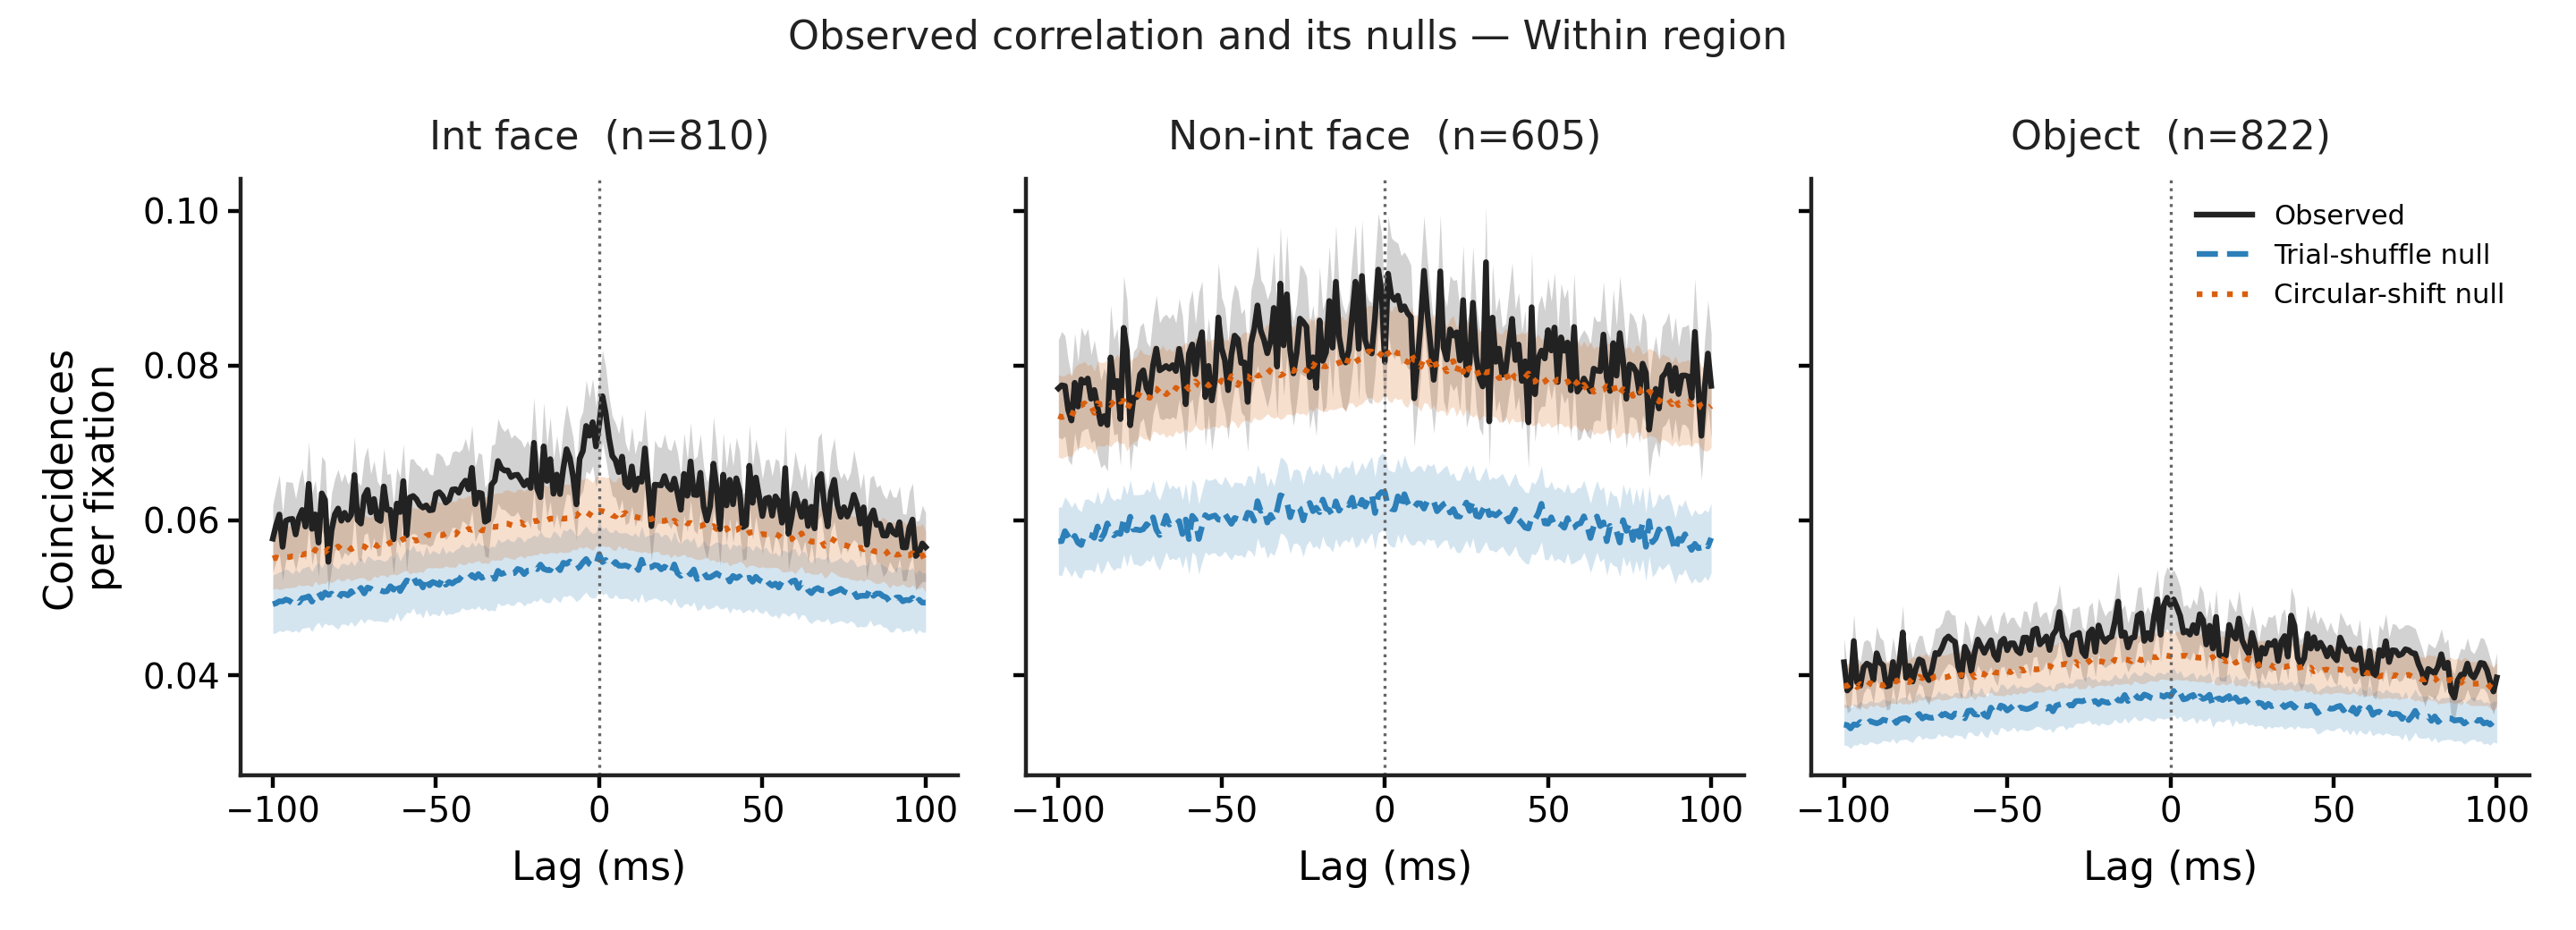

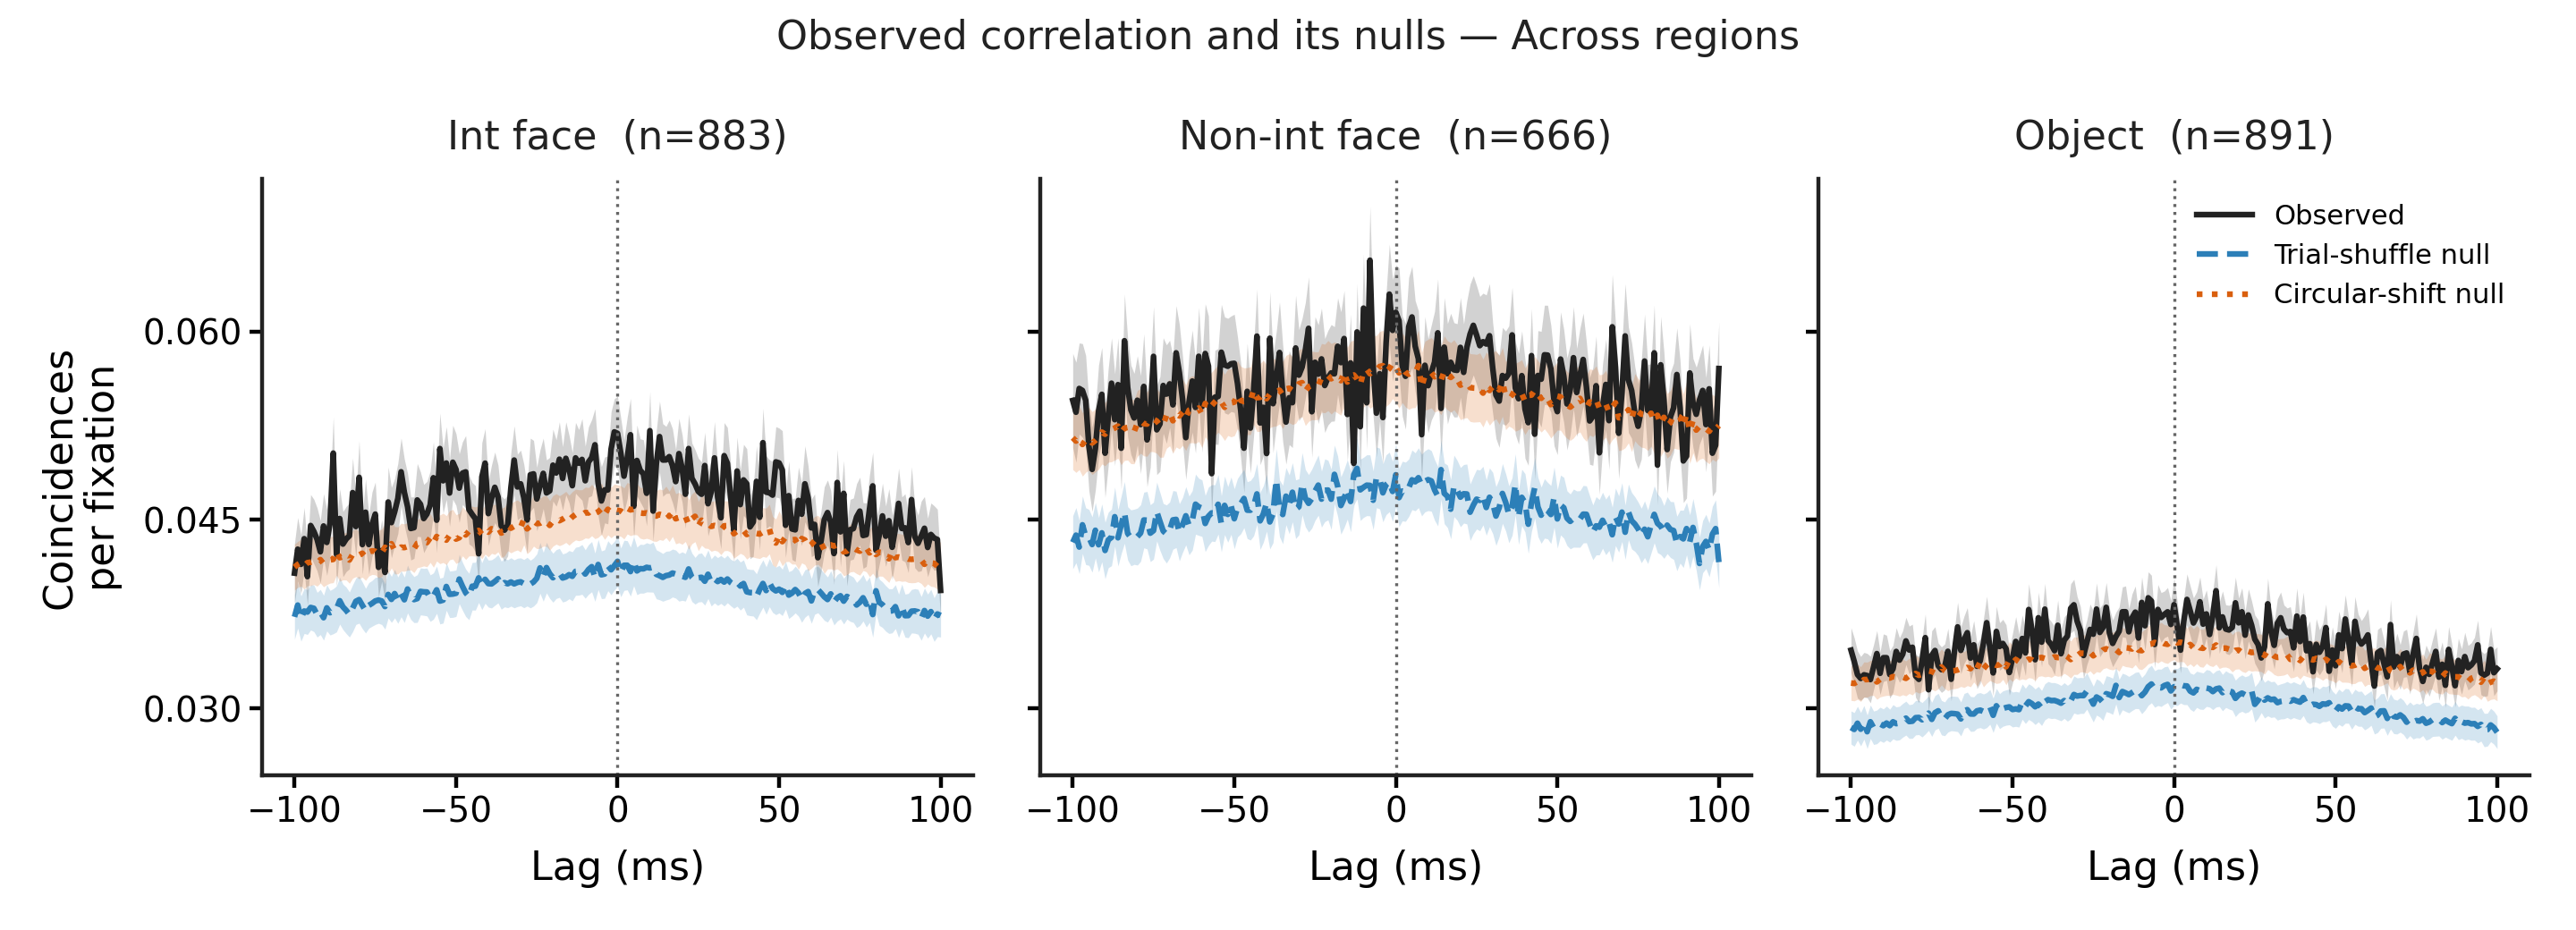

In [5]:
by_scope = pd.read_pickle(SUMMARY_DIR / "group_traces_by_scope.pkl")

for scope in ("within_region", "cross_region"):
    fig, paths = viz.plot_observed_and_nulls(by_scope, fig_settings, scope=scope)
    display(Image(filename=str(paths["png"])))

## 4. Excess over null, per region and per region pair

The same comparison as a **fractional excess over the trial-shuffle null**,
resolved per region (within) and per region pair (across). Zero is the null's own
expectation, and the y-axis is directly readable: 0.05 means 5% more
coincidences than chance.

The trial-shuffle null is the standard throughout — it holds each unit's
fixation-locked rate profile fixed and removes only trial-by-trial covariation.
The circular-shift panels follow as a timescale check.

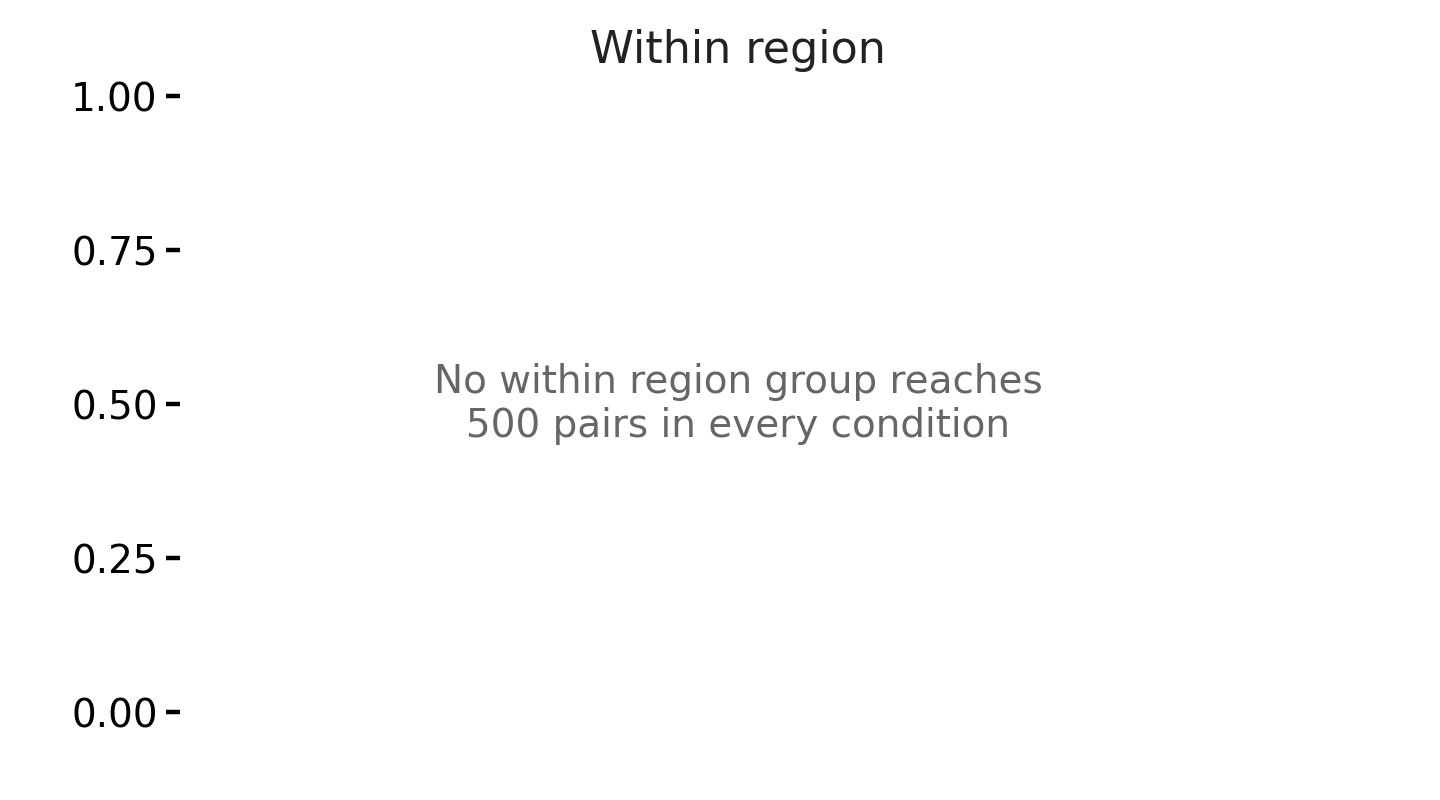

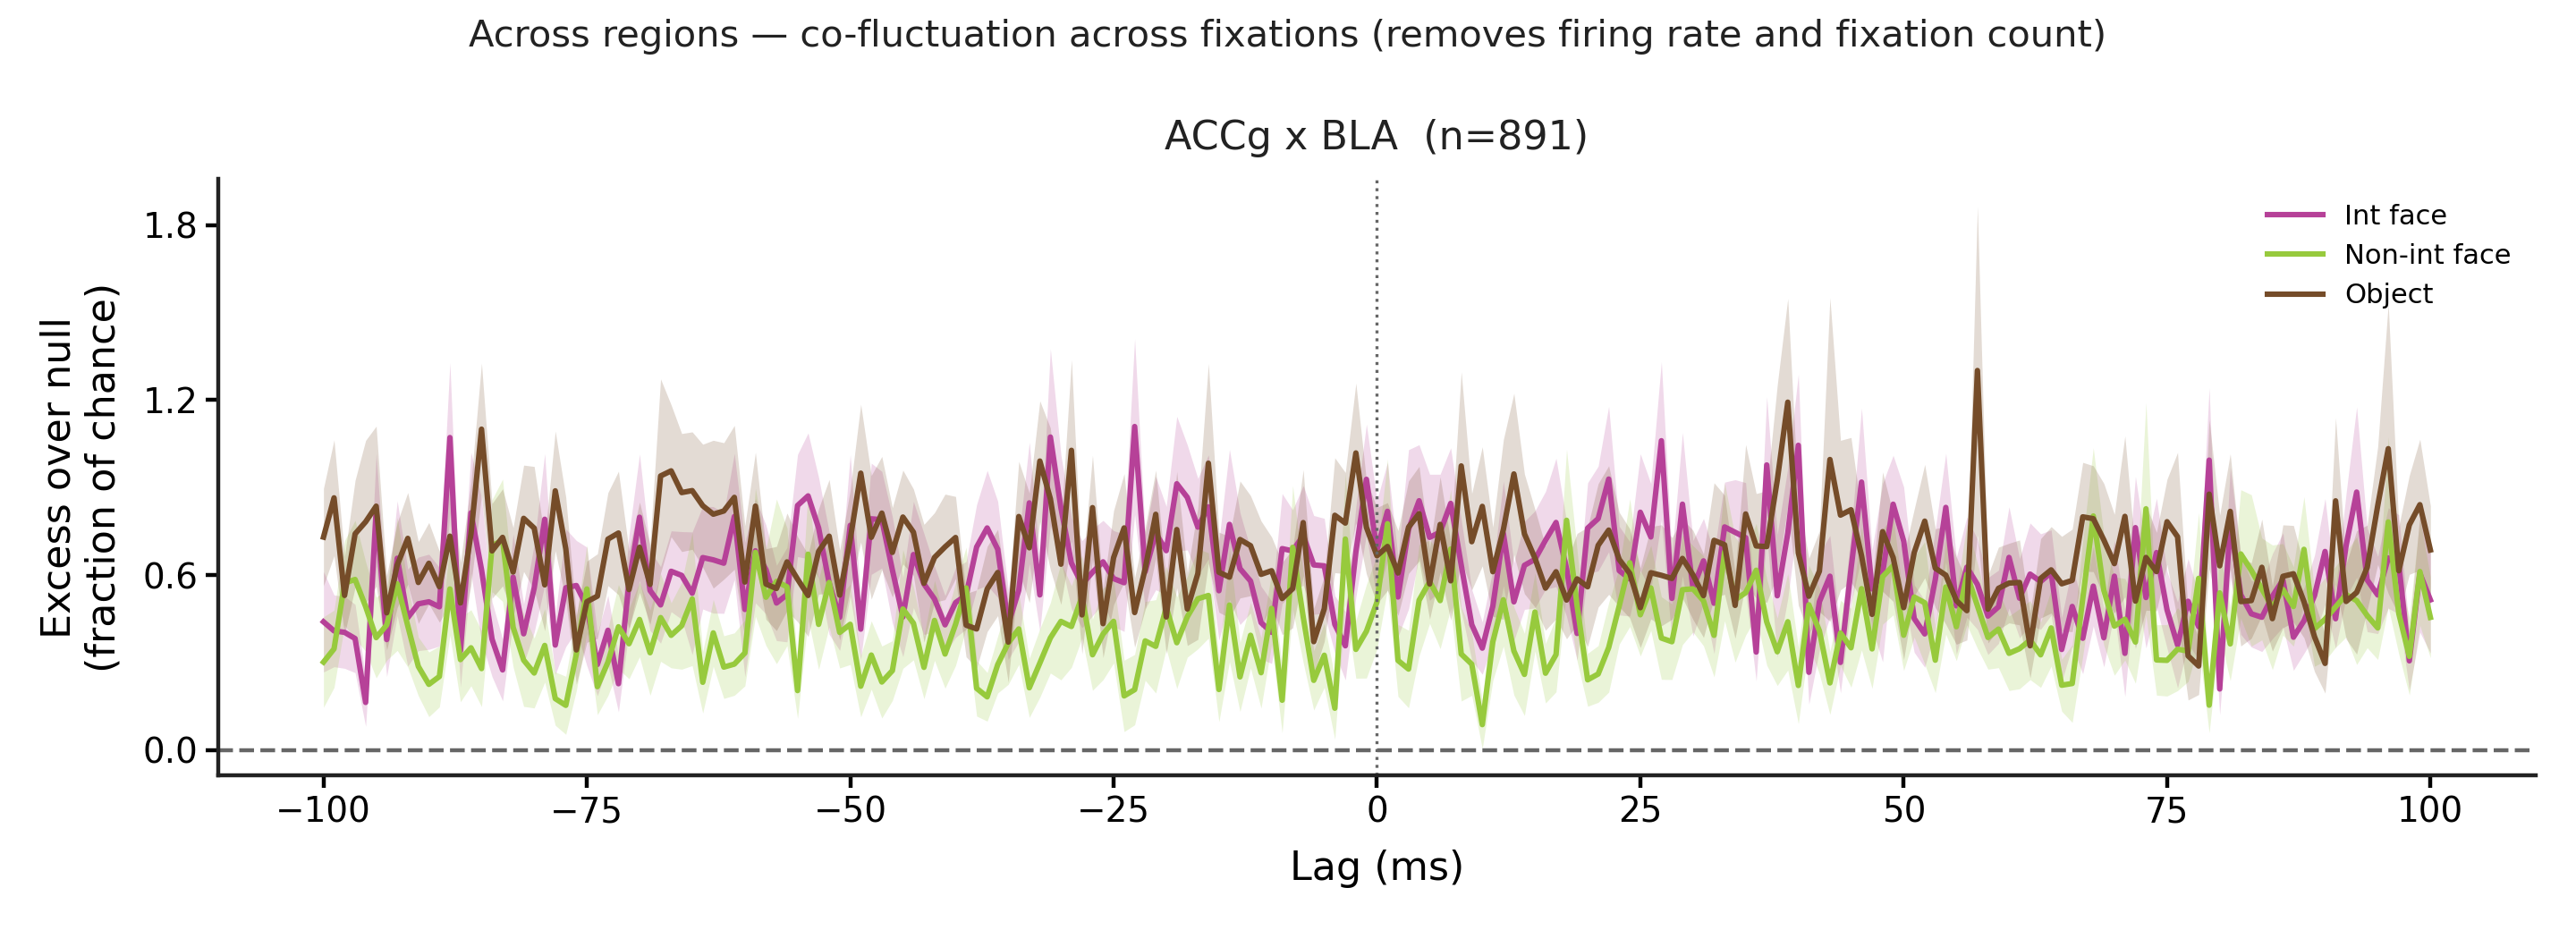

The same panels against the **circular-shift** null, as a timescale check. Structure present above the trial-shuffle null but absent here would be slow co-fluctuation rather than fine synchrony.

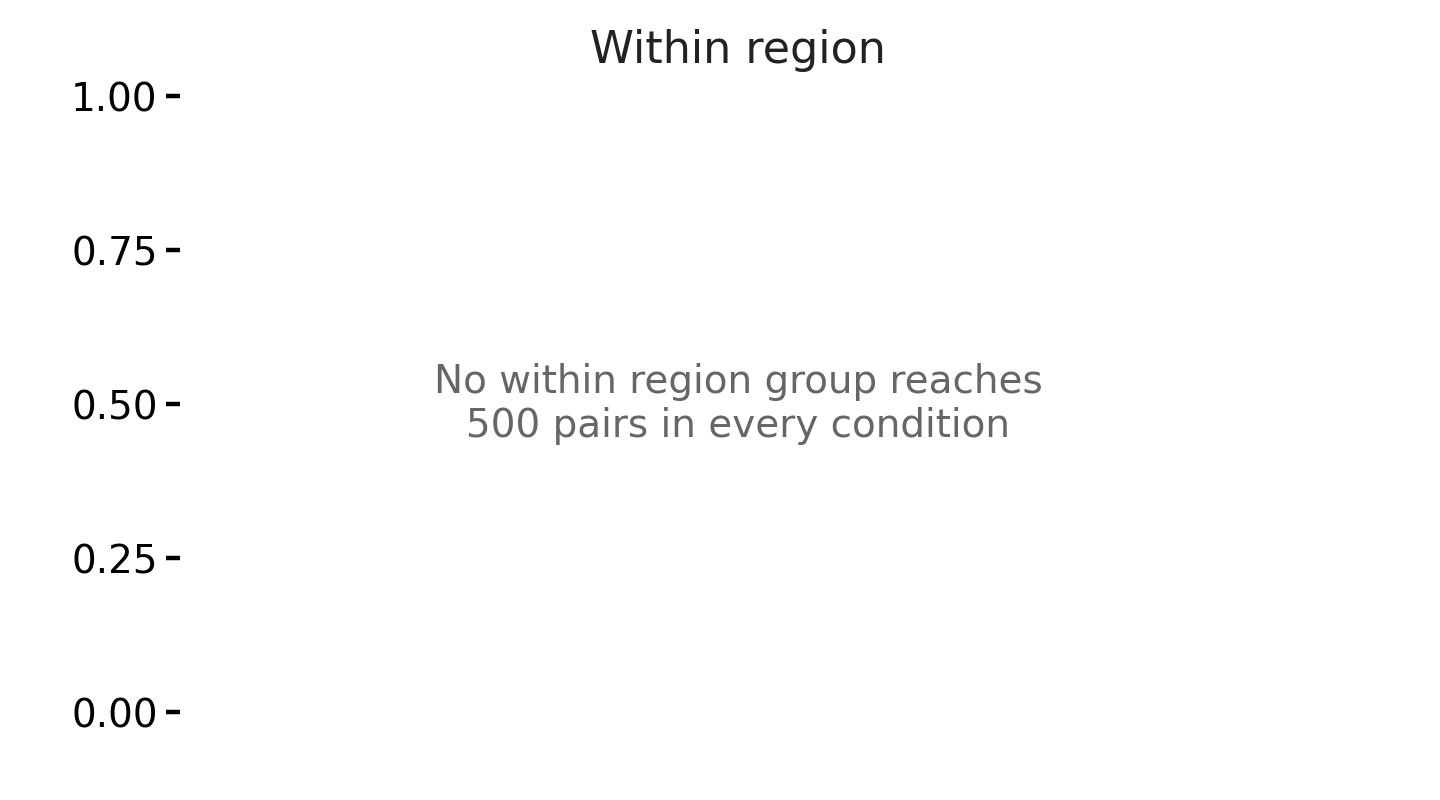

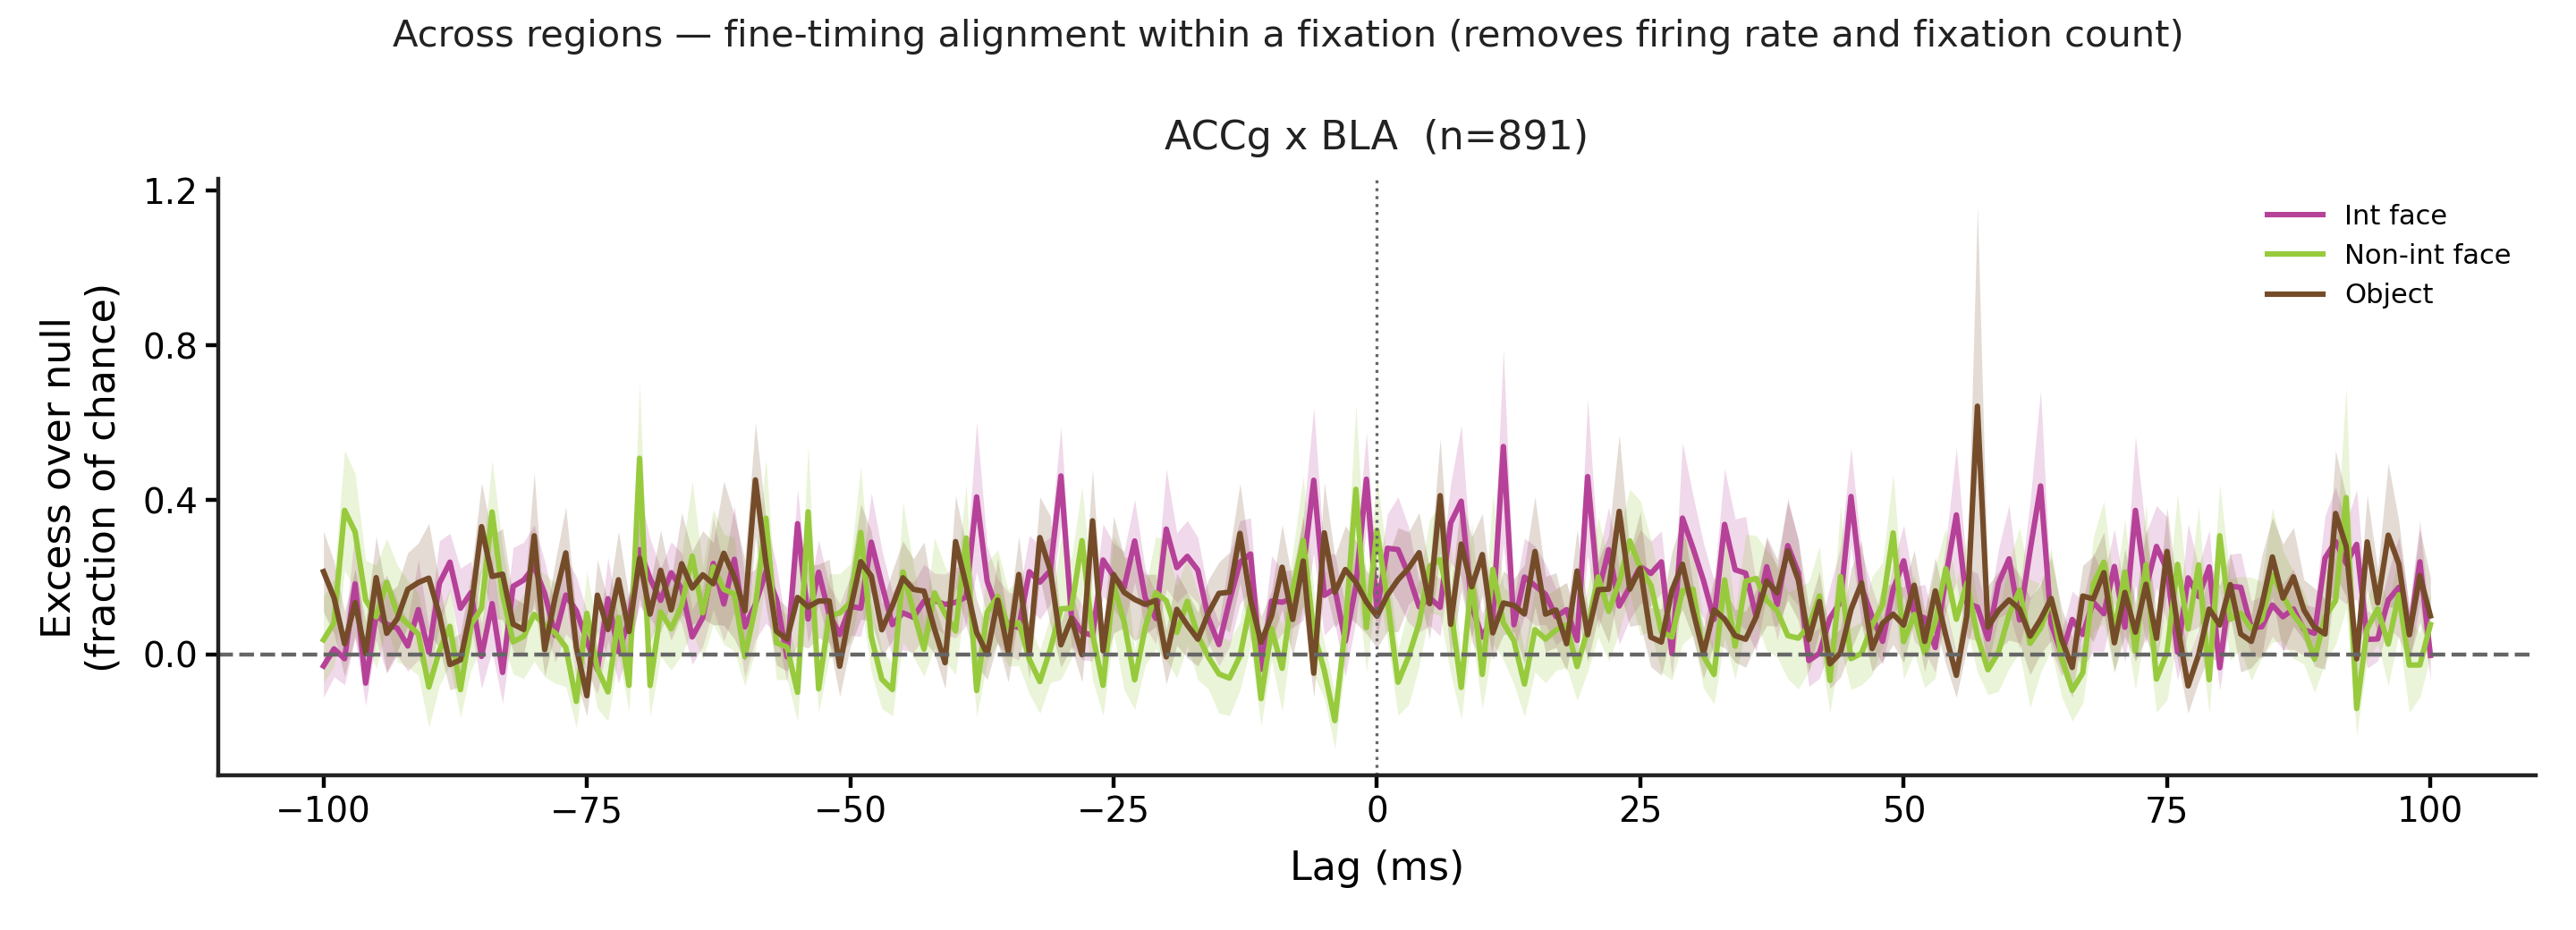

In [6]:
by_region = pd.read_pickle(SUMMARY_DIR / "group_traces_by_region.pkl")

for scope in ("within_region", "cross_region"):
    fig, paths = viz.plot_region_traces(
        by_region, fig_settings, scope=scope, null_name=NULL,
        metric="ratio", min_pairs=MIN_PAIRS,
    )
    display(Image(filename=str(paths["png"])))

display(Markdown(
    "The same panels against the **circular-shift** null, as a timescale check. "
    "Structure present above the trial-shuffle null but absent here would be slow "
    "co-fluctuation rather than fine synchrony."
))
for scope in ("within_region", "cross_region"):
    fig, paths = viz.plot_region_traces(
        by_region, fig_settings, scope=scope, null_name="circular_shift",
        metric="ratio", min_pairs=MIN_PAIRS,
    )
    display(Image(filename=str(paths["png"])))

### Does the answer depend on which metric is used?

Every contrast run under all three standardisations, merged onto one row. Where
they disagree the reason is a confound rather than a discovery, and the `ratio`
column is the one to trust.

In [7]:
across_metrics = pd.read_csv(SUMMARY_DIR / "condition_comparisons_across_metrics.csv")
display(across_metrics.round(4))

disagree = across_metrics.loc[~across_metrics["metrics_agree"].fillna(True)]
if len(disagree):
    display(Markdown(
        f"**{len(disagree)} of {len(across_metrics)} contrasts change significance "
        "depending on the metric.** Where that happens the ratio is the one to trust: "
        "`z` rewards conditions with more fixations, and interactive-face fixations "
        "outnumber the others several to one."
    ))
else:
    display(Markdown("_All contrasts agree across the three metrics._"))

,scope,region_pair,condition_a,condition_b,n_pairs,difference_ratio,p_ratio,significant_ratio,difference_effect,p_effect,significant_effect,difference_z,p_z,significant_z,metrics_agree
0,cross_region,accg-bla,face_interactive,face_non_interactive,639,0.0097,0.6860,False,-0.0014,0.0271,True,0.0533,0.0007,True,False
1,cross_region,accg-bla,face_interactive,object,844,0.0039,0.5607,False,0.0055,0.0011,True,-0.0039,0.0193,True,False
2,cross_region,accg-bla,face_non_interactive,object,648,-0.1646,0.1864,False,-0.0022,0.0716,False,-0.1000,0.0014,True,False
3,within_region,accg,face_interactive,face_non_interactive,258,-0.1955,0.0115,True,-0.0484,0.0271,True,0.0075,0.3969,False,False
4,within_region,accg,face_interactive,object,316,-0.4797,0.6860,False,0.0090,0.0067,True,-0.0033,0.0444,True,False
5,within_region,accg,face_non_interactive,object,258,0.0207,0.0360,True,0.0595,0.0010,True,0.0313,0.3727,False,False
6,within_region,bla,face_interactive,face_non_interactive,318,-0.0654,0.6860,False,0.0005,0.0942,False,0.0295,0.0528,False,True
7,within_region,bla,face_interactive,object,455,0.3292,0.0053,True,0.0153,0.0011,True,0.0639,0.0091,True,True
8,within_region,bla,face_non_interactive,object,328,0.0656,0.6860,False,0.0000,0.2150,False,-0.0454,0.2141,False,True


**6 of 9 contrasts change significance depending on the metric.** Where that happens the ratio is the one to trust: `z` rewards conditions with more fixations, and interactive-face fixations outnumber the others several to one.

### Supporting: is coordination above null at all?

Secondary to the condition comparison, but worth confirming there is something
to compare. One-sample Wilcoxon signed-rank test of the per-pair excess against
zero, per region and condition, using `z` — the right quantity for this question
and the wrong one for the comparison above.

,scope,region_pair,condition,n_pairs,mean_excess,median_excess,statistic,p_value
0,cross_region,accg-bla,face_interactive,883,0.3176,0.2135,309142.0,0.0000
1,cross_region,accg-bla,face_non_interactive,666,0.2095,0.0708,148391.0,0.0000
2,cross_region,accg-bla,object,891,0.3132,0.1384,293938.0,0.0000
3,within_region,accg,face_interactive,334,0.6810,0.5618,52851.0,0.0000
4,within_region,accg,face_non_interactive,258,0.6072,0.4563,30264.0,0.0000
5,within_region,accg,object,325,0.7025,0.4342,48166.0,0.0000
6,within_region,bla,face_interactive,476,0.2163,0.1036,79536.0,0.0000
7,within_region,bla,face_non_interactive,347,0.1255,-0.0354,33915.0,0.0232
8,within_region,bla,object,497,0.1516,0.0379,77666.0,0.0000


/gpfs/milgram/pi/chang/pg496/repositories/dal_monte_2022_analysis/src/dal_monte_2022_analysis/ephys/plotting/fixation_pair_spike_coordination.py:691: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend(frameon=False, fontsize=6, loc="best")


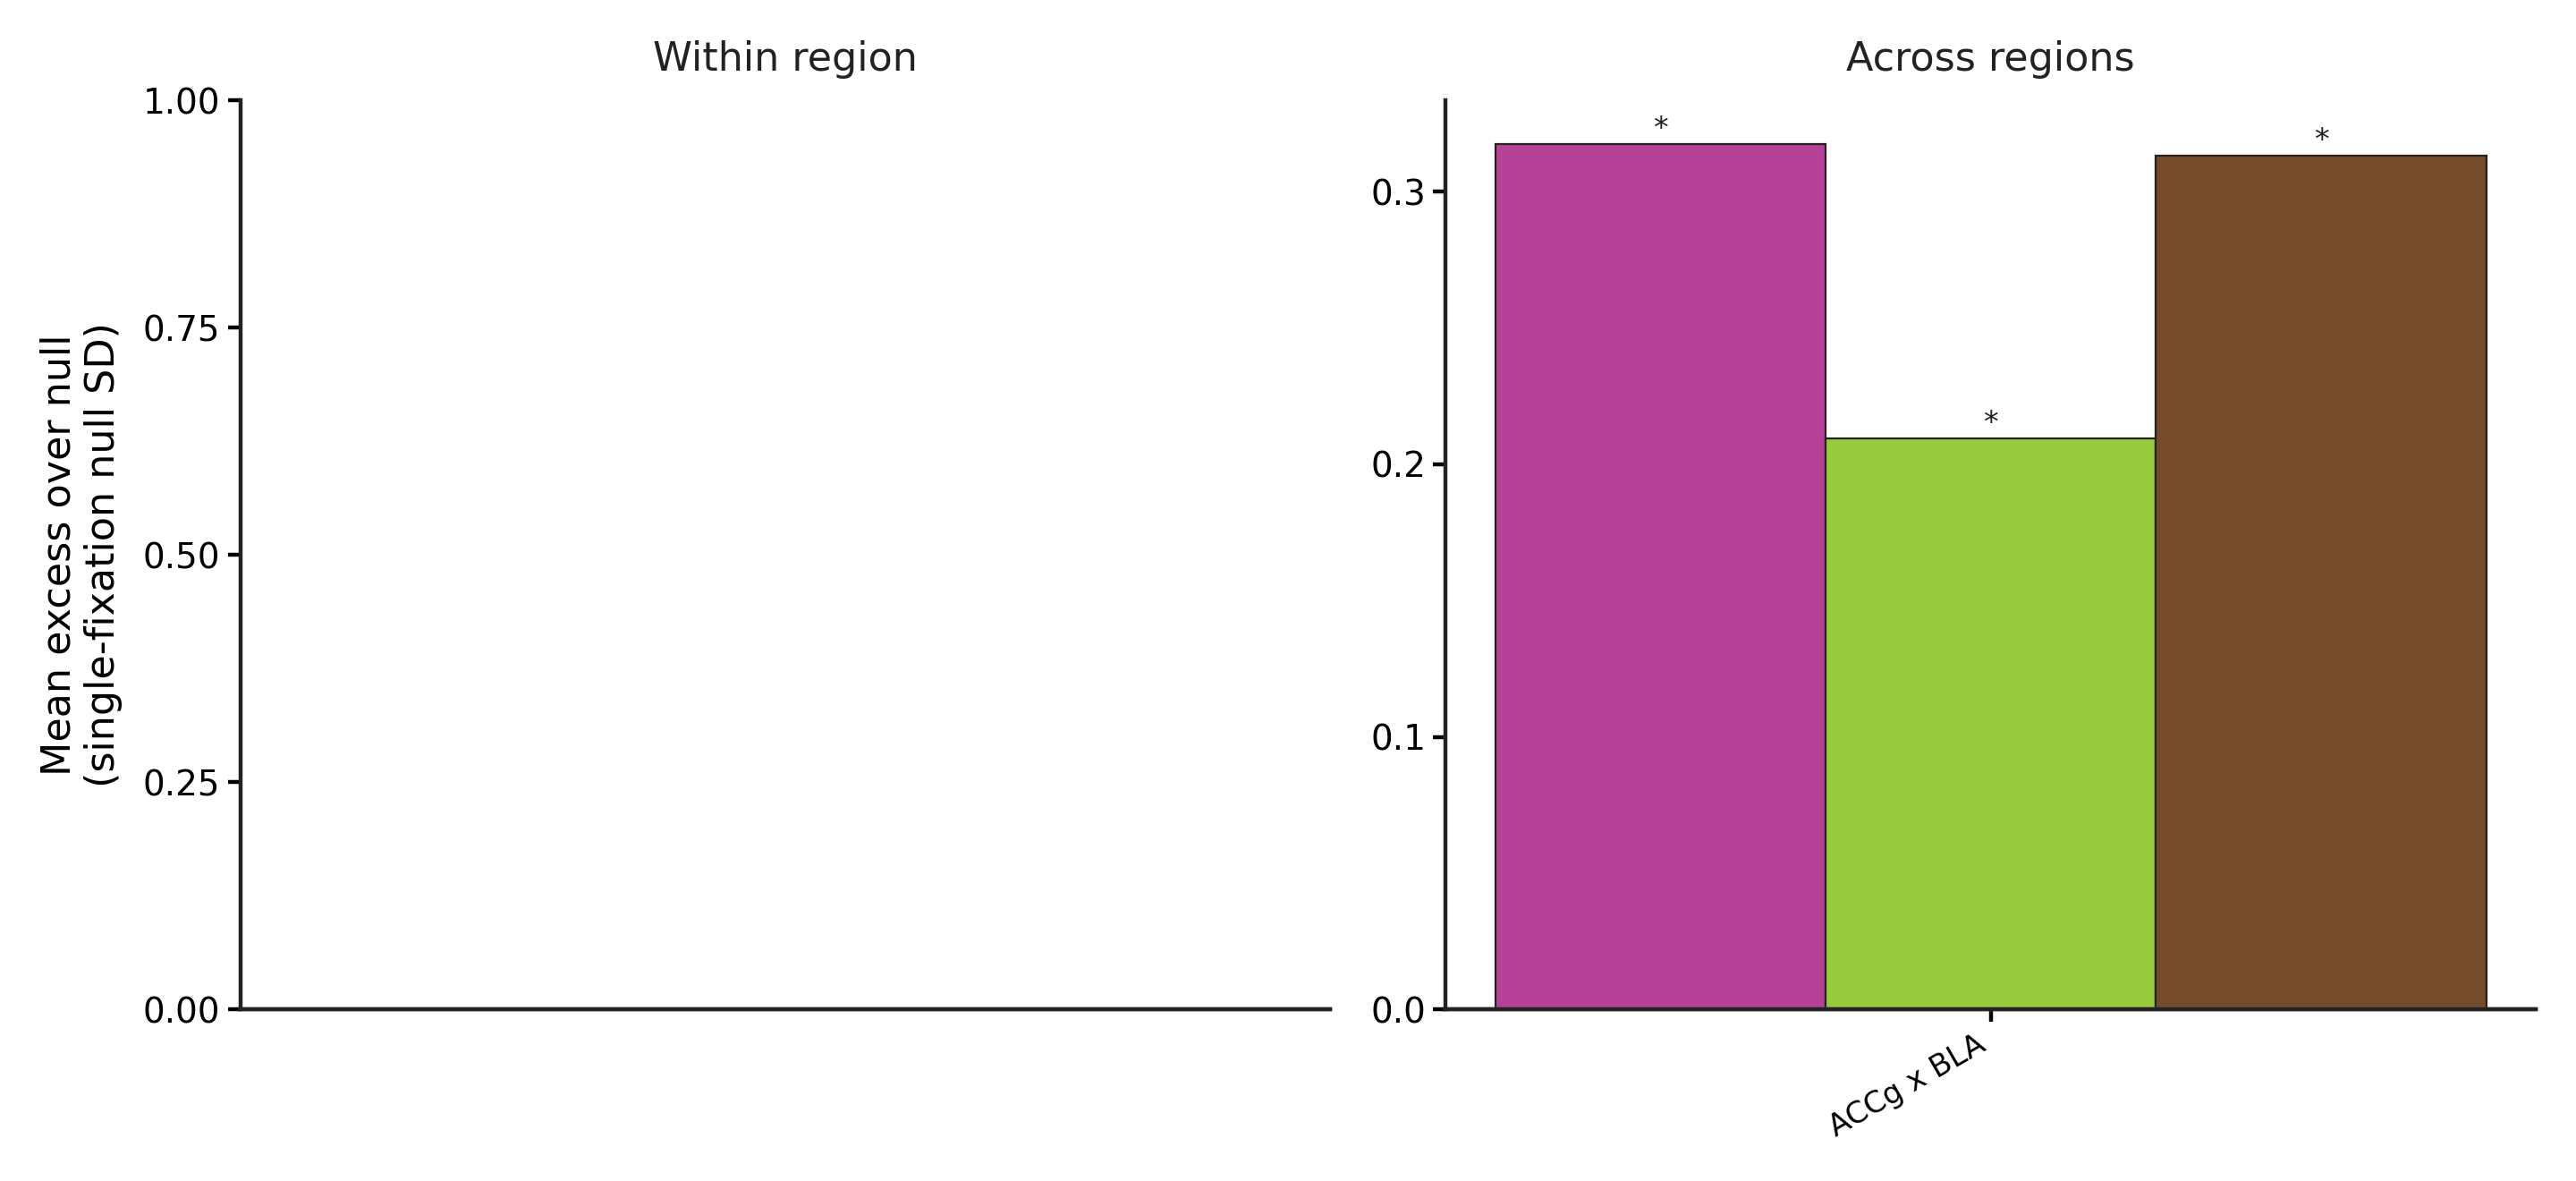

In [8]:
vs_null_by_region = pd.read_csv(SUMMARY_DIR / "coordination_vs_null_by_region.csv")
display(vs_null_by_region.round(4))

fig, paths = viz.plot_region_condition_tests(
    vs_null_by_region, fig_settings, min_pairs=MIN_PAIRS
)
display(Image(filename=str(paths["png"])))

## 5. Condition effects per region

Bootstrap confidence intervals on the per-pair effect, by region and region
pair.

,scope,region_pair,condition,n_pairs,n_pairs_finite,mean,sem,median,ci_low,ci_high,median_n_fixations,frac_pairs_above_null,mean_z
0,cross_region,accg-bla,face_interactive,883,883,0.7017,0.0644,0.2305,0.5814,0.8339,35.0,0.0204,0.3176
1,cross_region,accg-bla,face_non_interactive,666,666,0.3854,0.0453,0.1602,0.2992,0.4775,19.0,0.0315,0.2095
2,cross_region,accg-bla,object,891,891,0.6854,0.0874,0.1883,0.5269,0.8684,37.0,0.0258,0.3132
3,within_region,accg,face_interactive,334,334,0.8900,0.1148,0.3717,0.6871,1.1141,35.0,0.0479,0.6810
4,within_region,accg,face_non_interactive,258,258,0.7041,0.0755,0.4380,0.5676,0.8582,19.0,0.0465,0.6072
5,within_region,accg,object,325,325,1.3772,0.3237,0.3943,0.8462,2.0224,37.0,0.0523,0.7025
6,within_region,bla,face_interactive,476,476,0.6845,0.0904,0.2563,0.5146,0.8639,35.0,0.0126,0.2163
7,within_region,bla,face_non_interactive,347,347,0.4183,0.1150,-0.0074,0.2220,0.6666,19.0,0.0144,0.1255
8,within_region,bla,object,497,497,0.3532,0.0587,0.1046,0.2386,0.4690,37.0,0.0141,0.1516


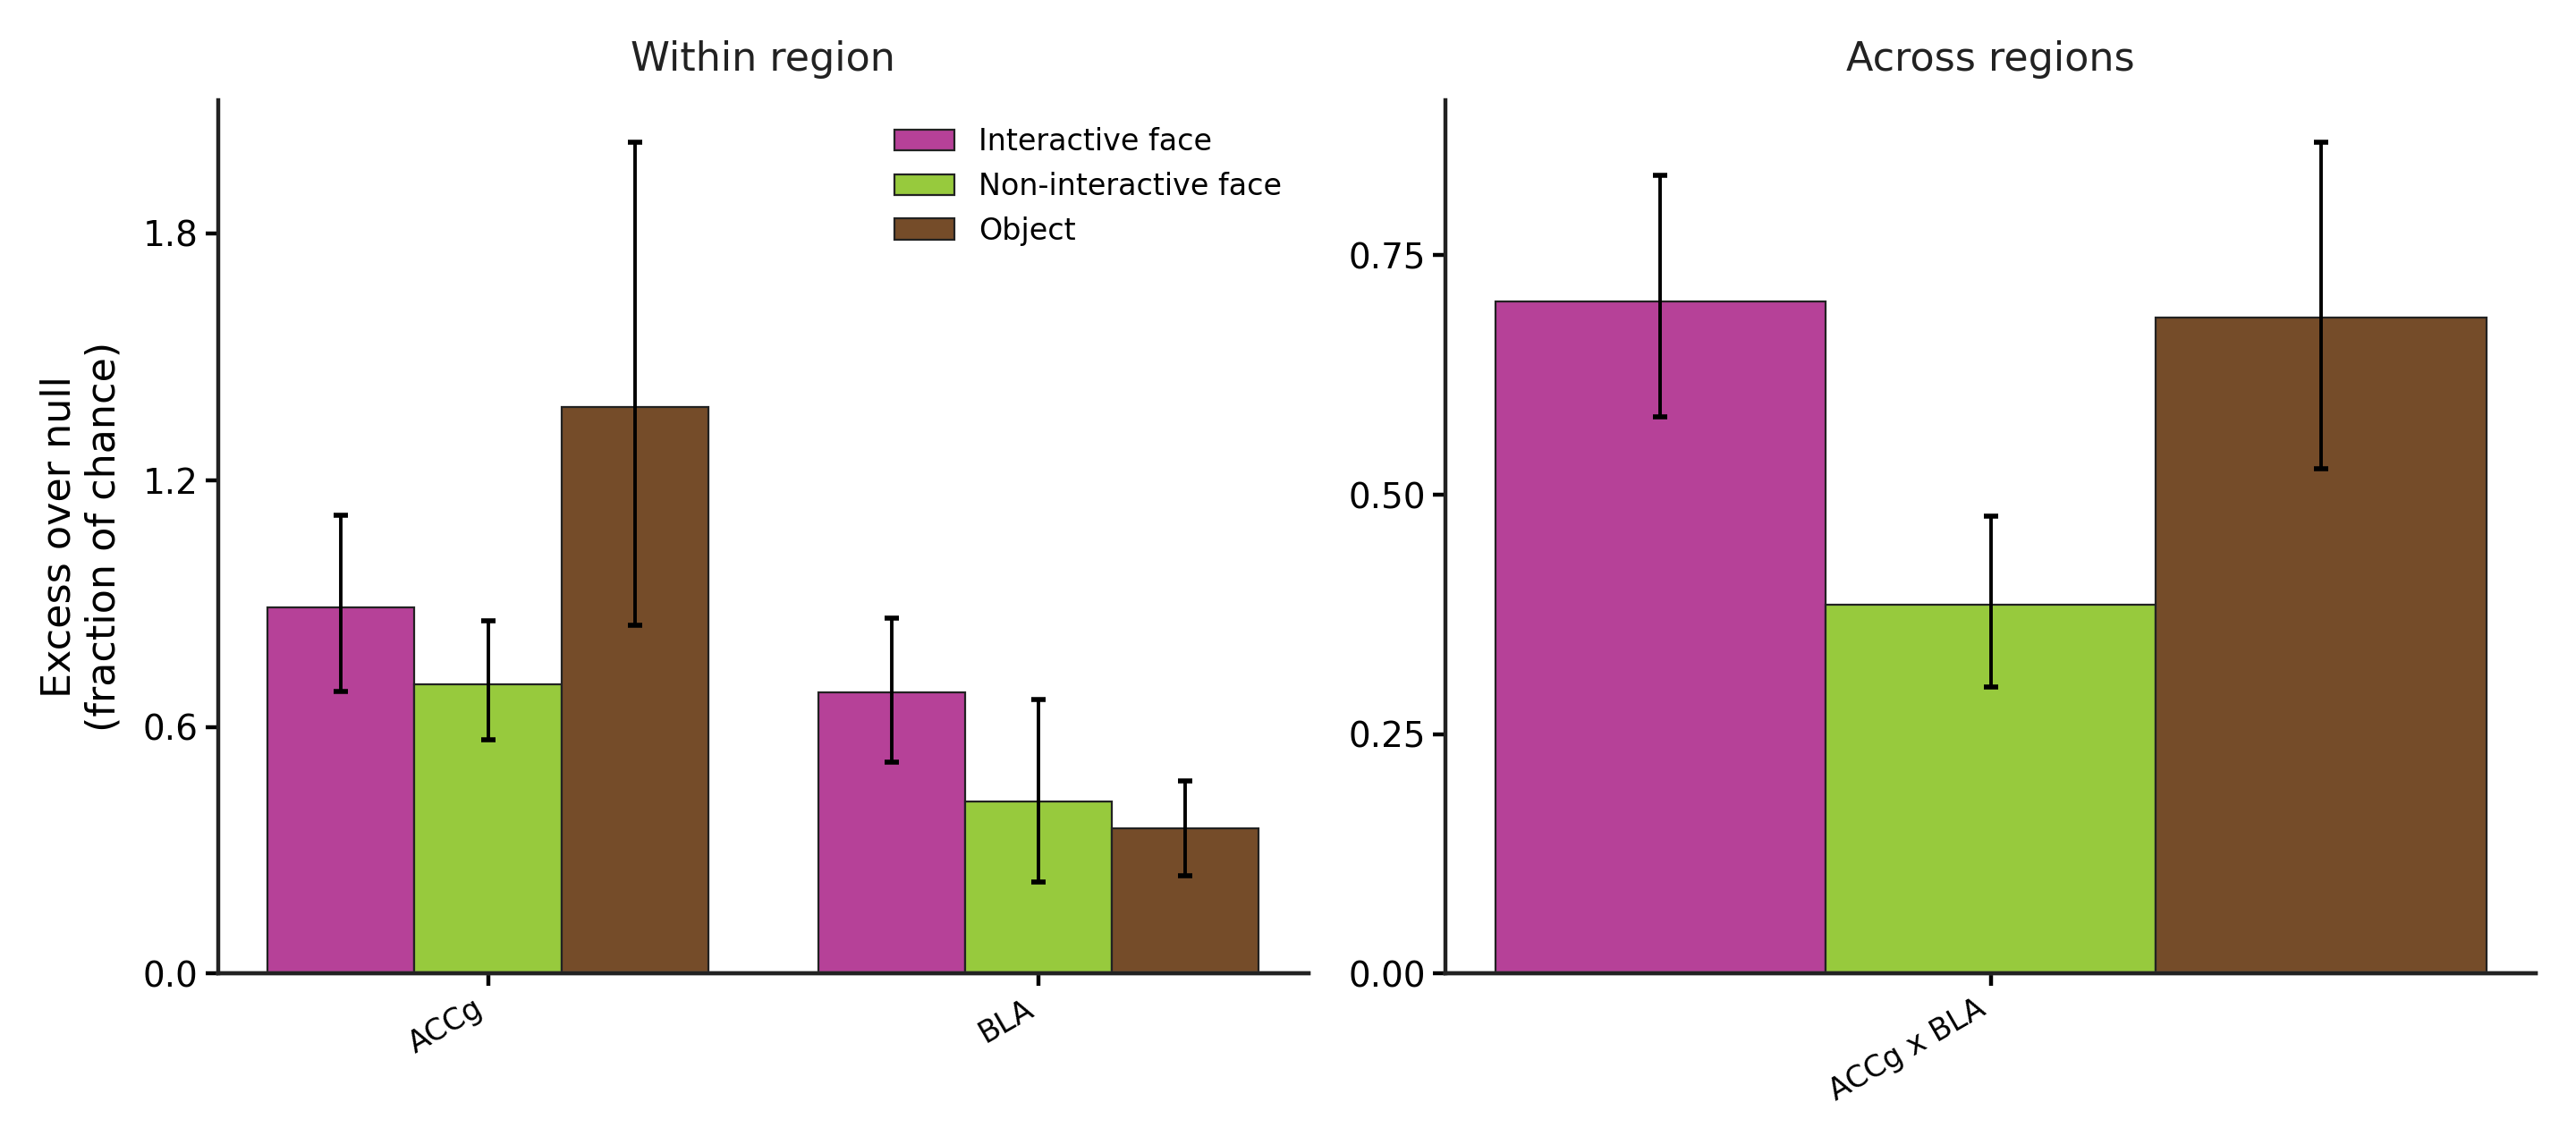

In [9]:
summary_by_region = pd.read_csv(SUMMARY_DIR / "coordination_summary_by_region.csv")
display(summary_by_region.round(4))

fig, paths = viz.plot_condition_effects(summary_by_region, fig_settings)
display(Image(filename=str(paths["png"])))

### Does interactive face change coordination, region by region?

Comparisons are **paired within pair**: the same two neurons, the same
electrodes, the same session, differing only in which fixations were used. That
removes pair identity, firing rate and recording quality in one step.
Benjamini–Hochberg corrected across the reported contrasts.

,scope,region_pair,condition_a,condition_b,n_pairs,mean_a,mean_b,mean_difference,statistic,p_value,effect_size_rank_biserial,p_value_corrected,significant,pvalue_correction
0,cross_region,accg-bla,face_interactive,face_non_interactive,639,0.4131,0.4034,0.0097,98469.5,0.6860,0.0142,0.6860,False,fdr_bh
1,cross_region,accg-bla,face_interactive,object,844,0.7405,0.7366,0.0039,165440.0,0.3115,0.0337,0.5607,False,fdr_bh
2,cross_region,accg-bla,face_non_interactive,object,648,0.3765,0.5412,-0.1646,95349.5,0.0828,-0.0575,0.1864,False,fdr_bh
3,within_region,accg,face_interactive,face_non_interactive,258,0.5086,0.7041,-0.1955,12979.0,0.0026,-0.1440,0.0115,True,fdr_bh
4,within_region,accg,face_interactive,object,316,0.9333,1.4130,-0.4797,24073.0,0.6157,0.0032,0.6860,False,fdr_bh
5,within_region,accg,face_non_interactive,object,258,0.7041,0.6834,0.0207,13580.0,0.0120,0.1440,0.0360,True,fdr_bh
6,within_region,bla,face_interactive,face_non_interactive,318,0.4335,0.4989,-0.0654,22879.0,0.5590,0.0844,0.6860,False,fdr_bh
7,within_region,bla,face_interactive,object,455,0.7088,0.3796,0.3292,38766.5,0.0006,0.1304,0.0053,True,fdr_bh
8,within_region,bla,face_non_interactive,object,328,0.4450,0.3794,0.0656,25027.0,0.6249,-0.0903,0.6860,False,fdr_bh


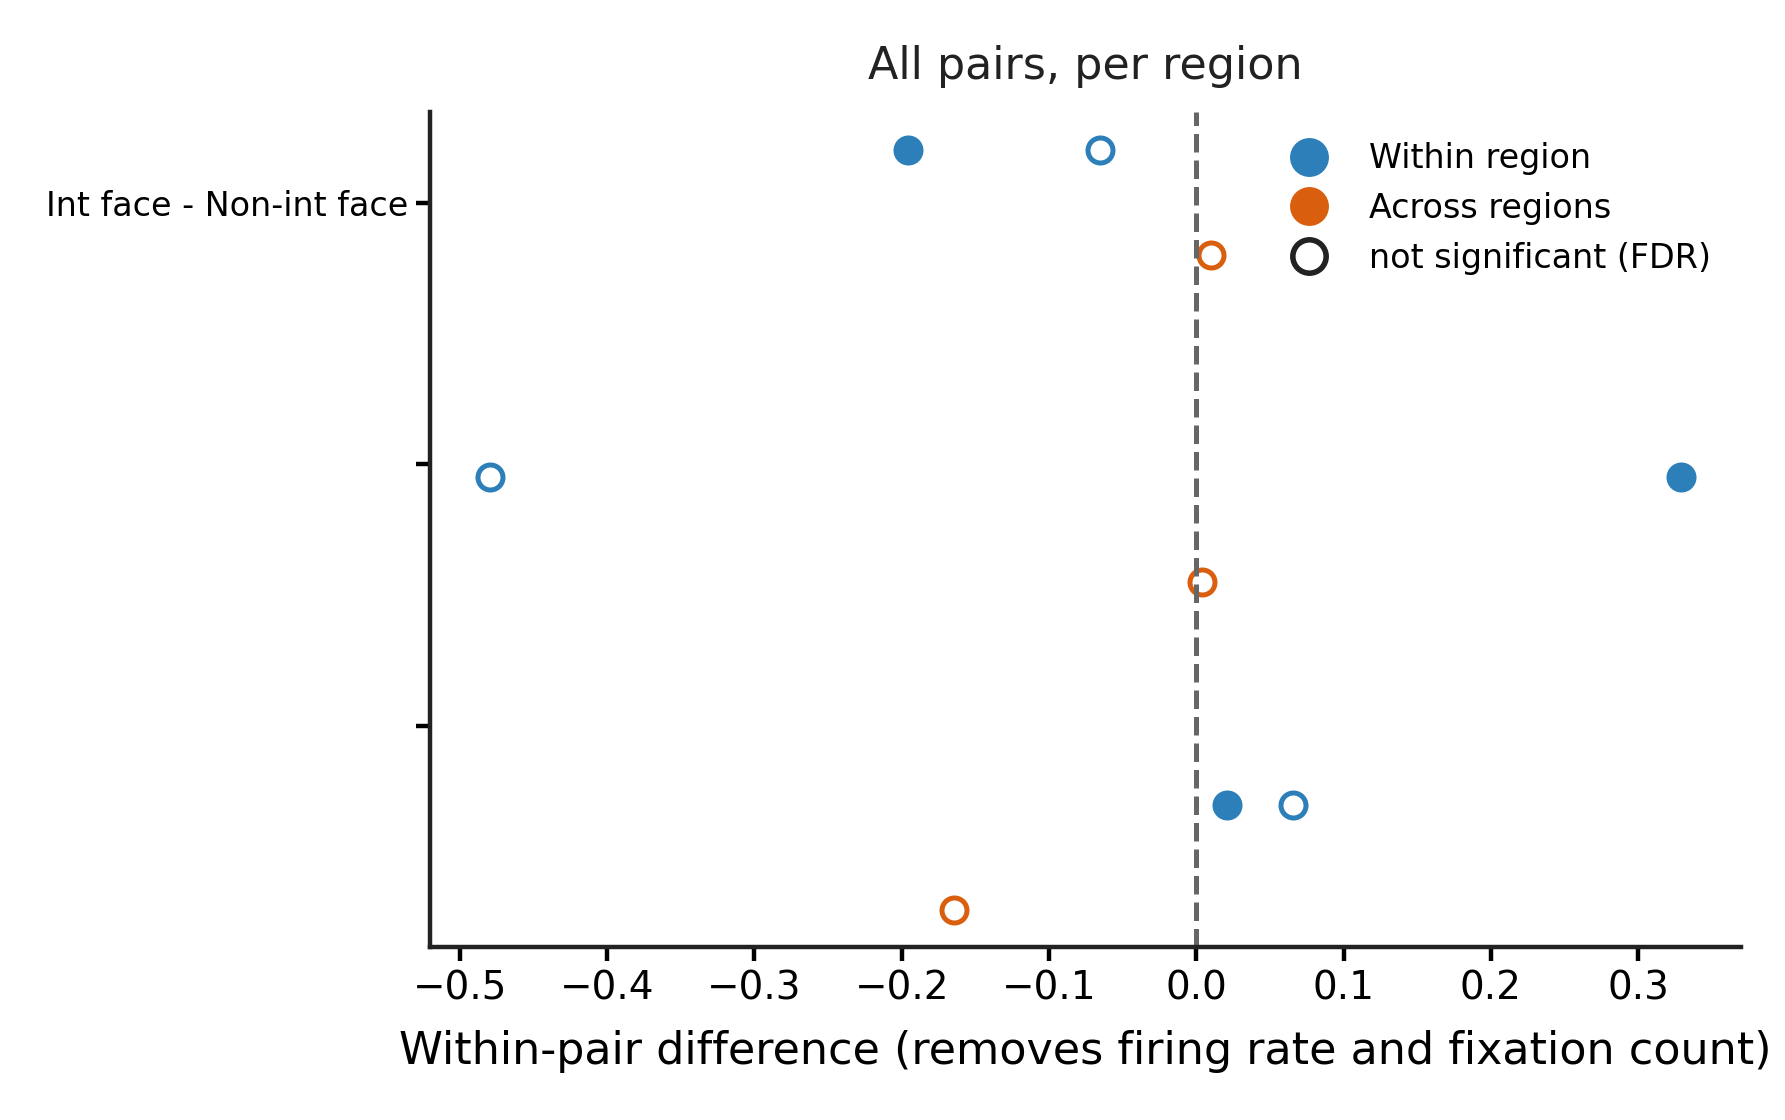

In [10]:
by_region_contrasts = pd.read_csv(SUMMARY_DIR / "condition_comparisons_by_region.csv")
display(by_region_contrasts.round(4))

fig, paths = viz.plot_condition_contrasts(
    by_region_contrasts, fig_settings,
    label="All pairs, per region", stem="fig05_condition_contrasts_by_region",
)
display(Image(filename=str(paths["png"])))

## 7. Pooled across regions

The same quantities pooled to scope level, as a summary of the region-resolved
results above. Read these *after* the per-region sections, and treat a pooled
effect that no individual region shows as a composition artifact rather than a
finding.

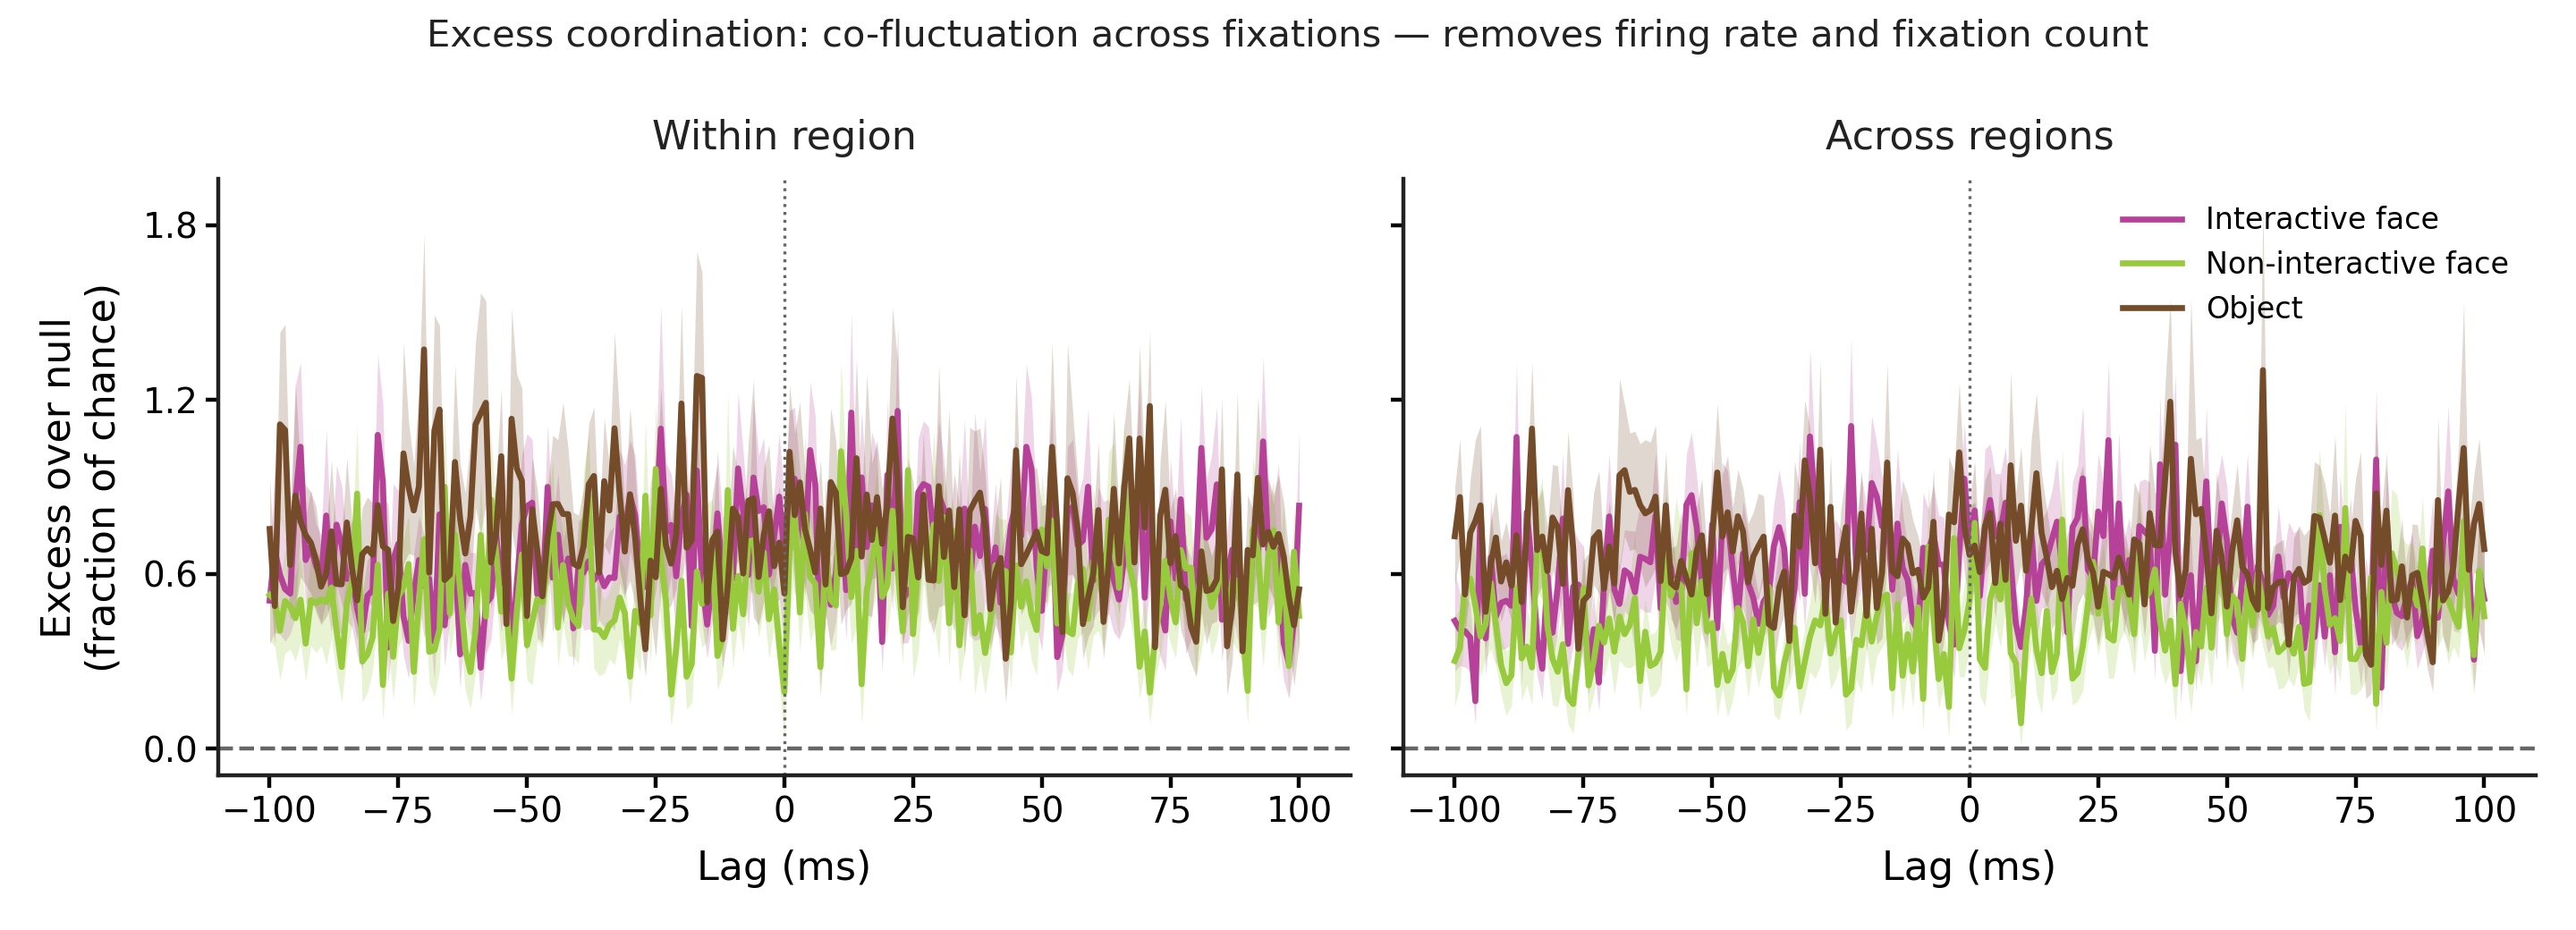

,scope,condition_a,condition_b,n_pairs,mean_a,mean_b,mean_difference,statistic,p_value,effect_size_rank_biserial,p_value_corrected,significant,pvalue_correction
0,cross_region,face_interactive,face_non_interactive,639,0.4131,0.4034,0.0097,98469.5,0.6860,0.0142,0.6860,False,fdr_bh
1,cross_region,face_interactive,object,844,0.7405,0.7366,0.0039,165440.0,0.3115,0.0337,0.3738,False,fdr_bh
2,cross_region,face_non_interactive,object,648,0.3765,0.5412,-0.1646,95349.5,0.0828,-0.0575,0.2485,False,fdr_bh
3,within_region,face_interactive,face_non_interactive,576,0.4672,0.5908,-0.1237,75194.0,0.2208,-0.0195,0.3738,False,fdr_bh
4,within_region,face_interactive,object,771,0.8008,0.8032,-0.0023,127174.5,0.0157,0.0771,0.0945,False,fdr_bh
5,within_region,face_non_interactive,object,586,0.5591,0.5132,0.0458,79515.0,0.3015,0.0138,0.3738,False,fdr_bh


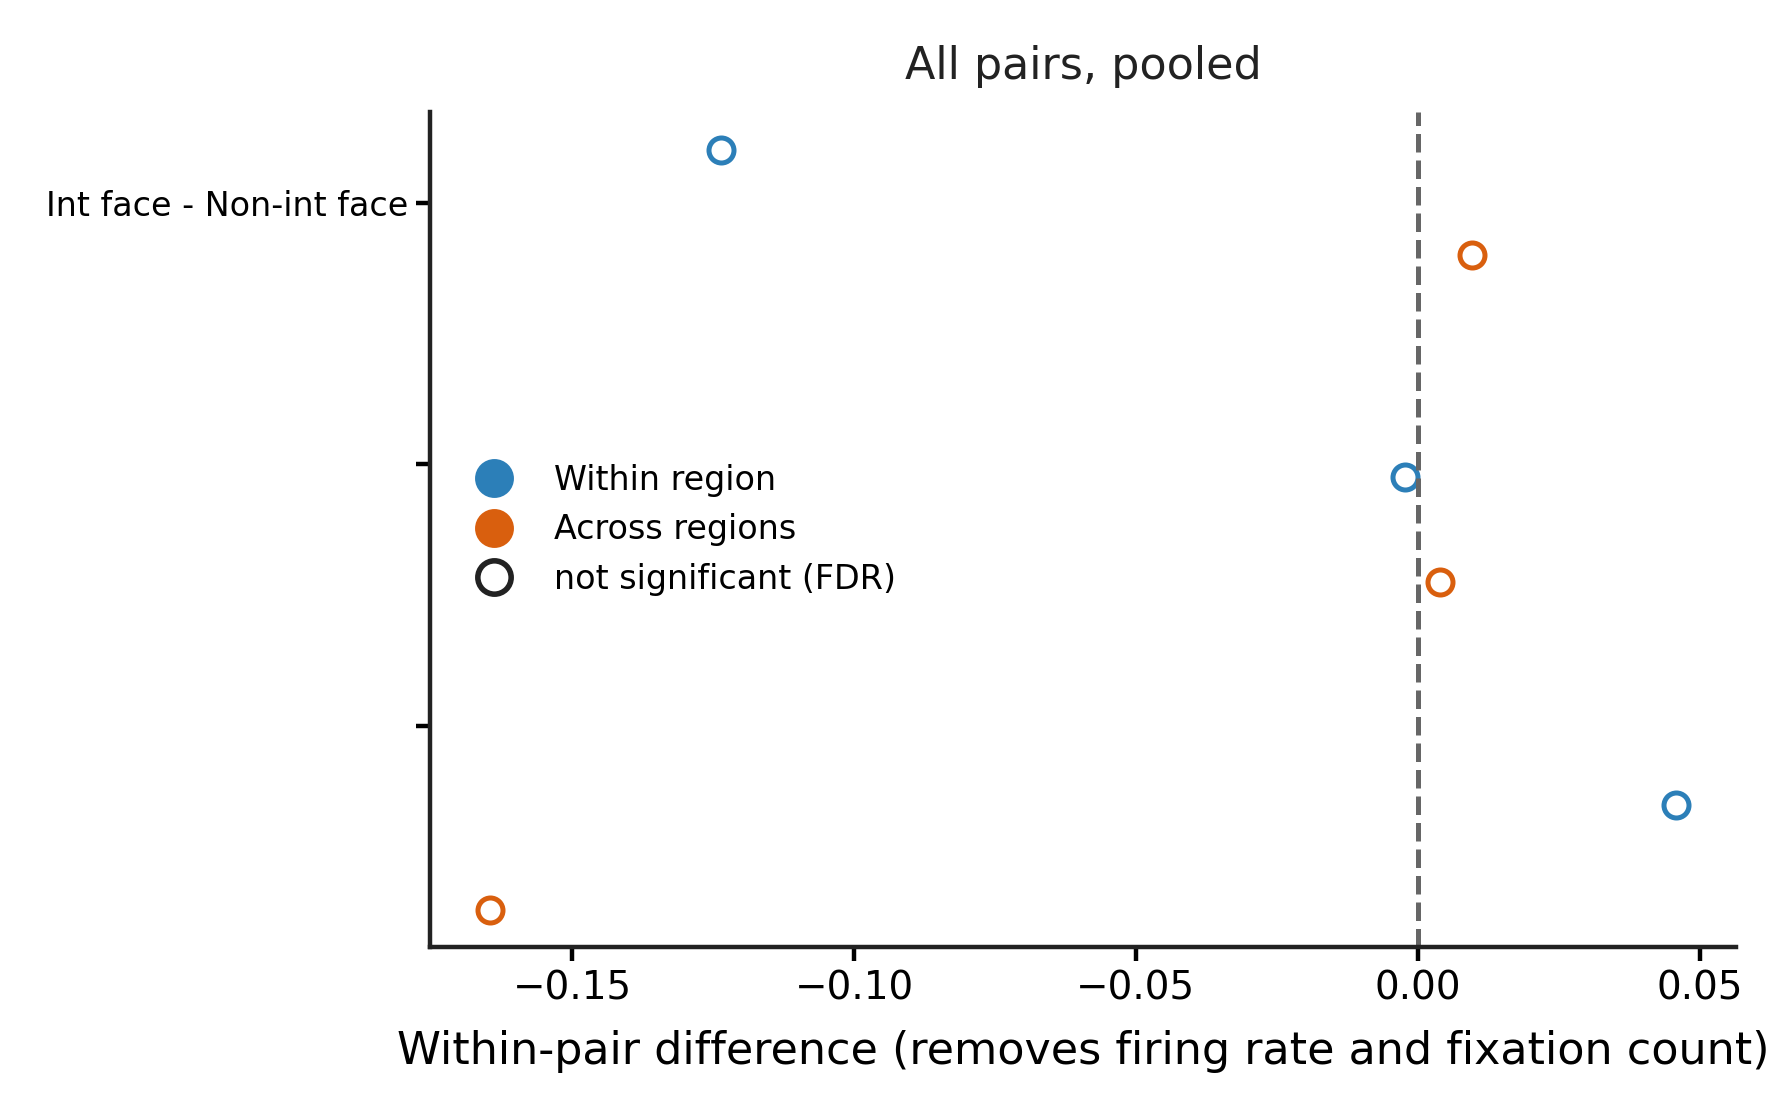

In [11]:
fig, paths = viz.plot_group_traces(by_scope, fig_settings, null_name=NULL, metric="ratio")
display(Image(filename=str(paths["png"])))

comparisons = pd.read_csv(SUMMARY_DIR / "condition_comparisons.csv")
display(comparisons.round(4))
fig, paths = viz.plot_condition_contrasts(comparisons, fig_settings, label="All pairs, pooled", stem="fig08_condition_contrasts_pooled")
display(Image(filename=str(paths["png"])))

## 8. Control: trial-count matching

The `effect` metric is already built not to scale with trial count. This is the
direct check: every pair recomputed on a common fixation count across
conditions. **If a condition difference survives here, trial count is not
driving it.**

,scope,region_pair,condition_a,condition_b,n_pairs,mean_a,mean_b,mean_difference,statistic,p_value,effect_size_rank_biserial,p_value_corrected,significant,pvalue_correction
0,cross_region,accg-bla,face_interactive,face_non_interactive,638,0.4190,0.4448,-0.0258,89298.5,0.2742,-0.0343,0.4935,False,fdr_bh
1,cross_region,accg-bla,face_interactive,object,727,0.4177,0.3242,0.0935,110553.0,0.7136,-0.0179,0.8615,False,fdr_bh
2,cross_region,accg-bla,face_non_interactive,object,647,0.4014,0.3713,0.0301,93397.0,0.7658,0.0179,0.8615,False,fdr_bh
3,within_region,accg,face_interactive,face_non_interactive,257,0.3870,0.7895,-0.4026,10105.0,0.0000,-0.2835,0.0000,True,fdr_bh
4,within_region,accg,face_interactive,object,276,0.5342,0.5528,-0.0186,16195.0,0.4008,-0.0763,0.6012,False,fdr_bh
5,within_region,accg,face_non_interactive,object,258,0.7826,0.5654,0.2172,12203.0,0.0023,0.1920,0.0105,True,fdr_bh
6,within_region,bla,face_interactive,face_non_interactive,317,0.3482,0.4851,-0.1369,18570.0,0.0938,-0.0727,0.2815,False,fdr_bh
7,within_region,bla,face_interactive,object,386,0.2262,0.1346,0.0916,24334.0,0.9600,0.0192,0.9600,False,fdr_bh
8,within_region,bla,face_non_interactive,object,328,0.4350,0.3122,0.1228,20348.5,0.2300,0.0303,0.4935,False,fdr_bh


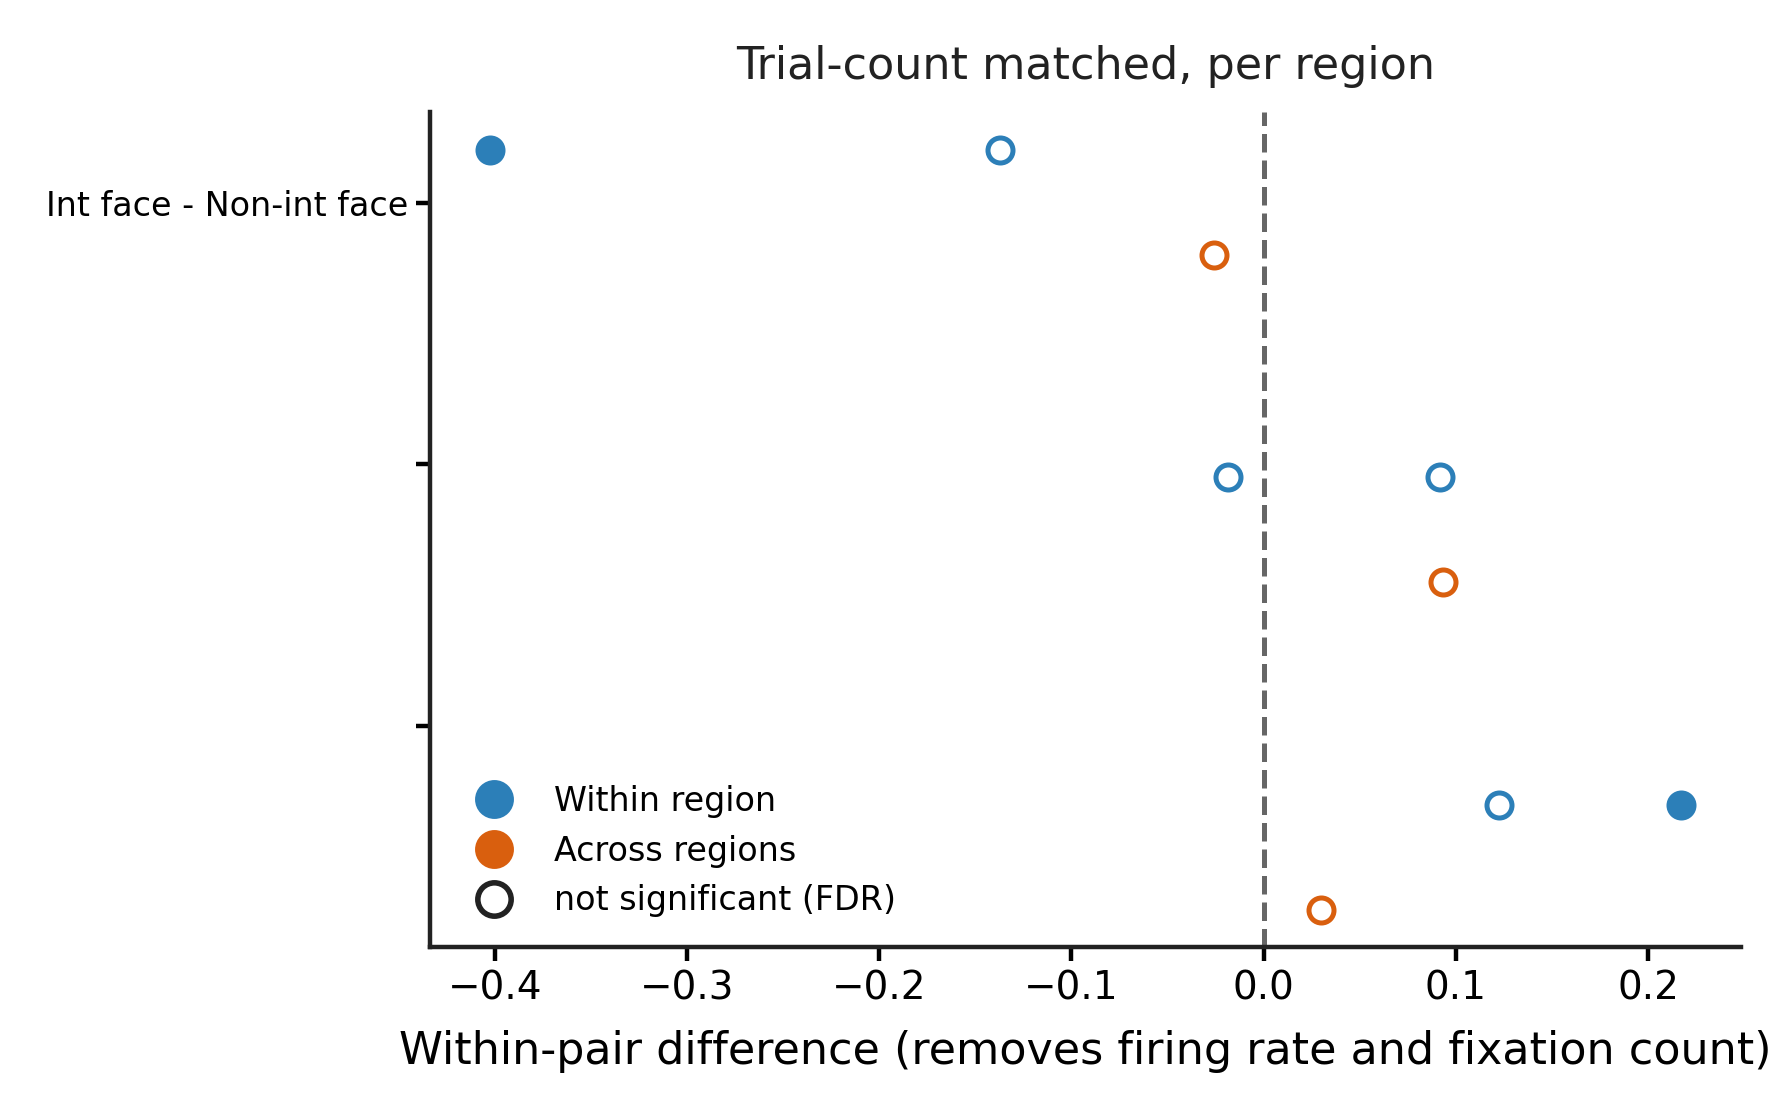

,scope,region_pair,condition_a,condition_b,mean_difference_full,mean_difference_matched,significant_full,significant_matched
0,cross_region,accg-bla,face_interactive,face_non_interactive,0.0097,-0.0258,False,False
1,cross_region,accg-bla,face_interactive,object,0.0039,0.0935,False,False
2,cross_region,accg-bla,face_non_interactive,object,-0.1646,0.0301,False,False
3,within_region,accg,face_interactive,face_non_interactive,-0.1955,-0.4026,True,True
4,within_region,accg,face_interactive,object,-0.4797,-0.0186,False,False
5,within_region,accg,face_non_interactive,object,0.0207,0.2172,True,True
6,within_region,bla,face_interactive,face_non_interactive,-0.0654,-0.1369,False,False
7,within_region,bla,face_interactive,object,0.3292,0.0916,True,False
8,within_region,bla,face_non_interactive,object,0.0656,0.1228,False,False


In [12]:
matched_metric = EFFECT_METRIC + "_matched"
if matched_metric in pairs.columns and pairs[matched_metric].notna().any():
    matched = psc.compare_conditions(
        pairs, metric=matched_metric, group_columns=("scope", "region_pair")
    )
    display(matched.round(4))
    fig, paths = viz.plot_condition_contrasts(
        matched, fig_settings,
        label="Trial-count matched, per region", stem="fig09_contrasts_matched",
    )
    display(Image(filename=str(paths["png"])))
    merged = by_region_contrasts.merge(
        matched, on=["scope", "region_pair", "condition_a", "condition_b"],
        suffixes=("_full", "_matched"),
    )
    display(
        merged.loc[
            :,
            ["scope", "region_pair", "condition_a", "condition_b",
             "mean_difference_full", "mean_difference_matched",
             "significant_full", "significant_matched"],
        ].round(4)
    )
else:
    display(Markdown("_Trial-count-matched columns are absent; rebuild with `trial_match_conditions: true`._"))

## 9. Pairs where both units are FDR-selective

Everything above used **all** recorded pairs. This repeats it on pairs where
both units are significantly selective for at least one fixation-condition
contrast (FDR-corrected, `three_condition_core`).

This is a sensitivity check, not independent confirmation — selecting units by a
condition contrast and then asking whether coordination differs by condition is
circular. What it can legitimately show is whether an effect is carried by the
selective subset or is distributed across the population.

pairs with both units FDR-selective: 2,170 of 4,677 (46.4%)


,scope,condition,n_pairs,n_pairs_both_selective,n_dates,n_sessions,median_n_fixations
0,cross_region,face_interactive,414,414,1,9,37.0
1,cross_region,face_non_interactive,326,326,1,8,19.0
2,cross_region,object,428,428,1,9,37.0
3,within_region,face_interactive,356,356,1,9,37.0
4,within_region,face_non_interactive,279,279,1,8,19.0
5,within_region,object,367,367,1,9,37.0


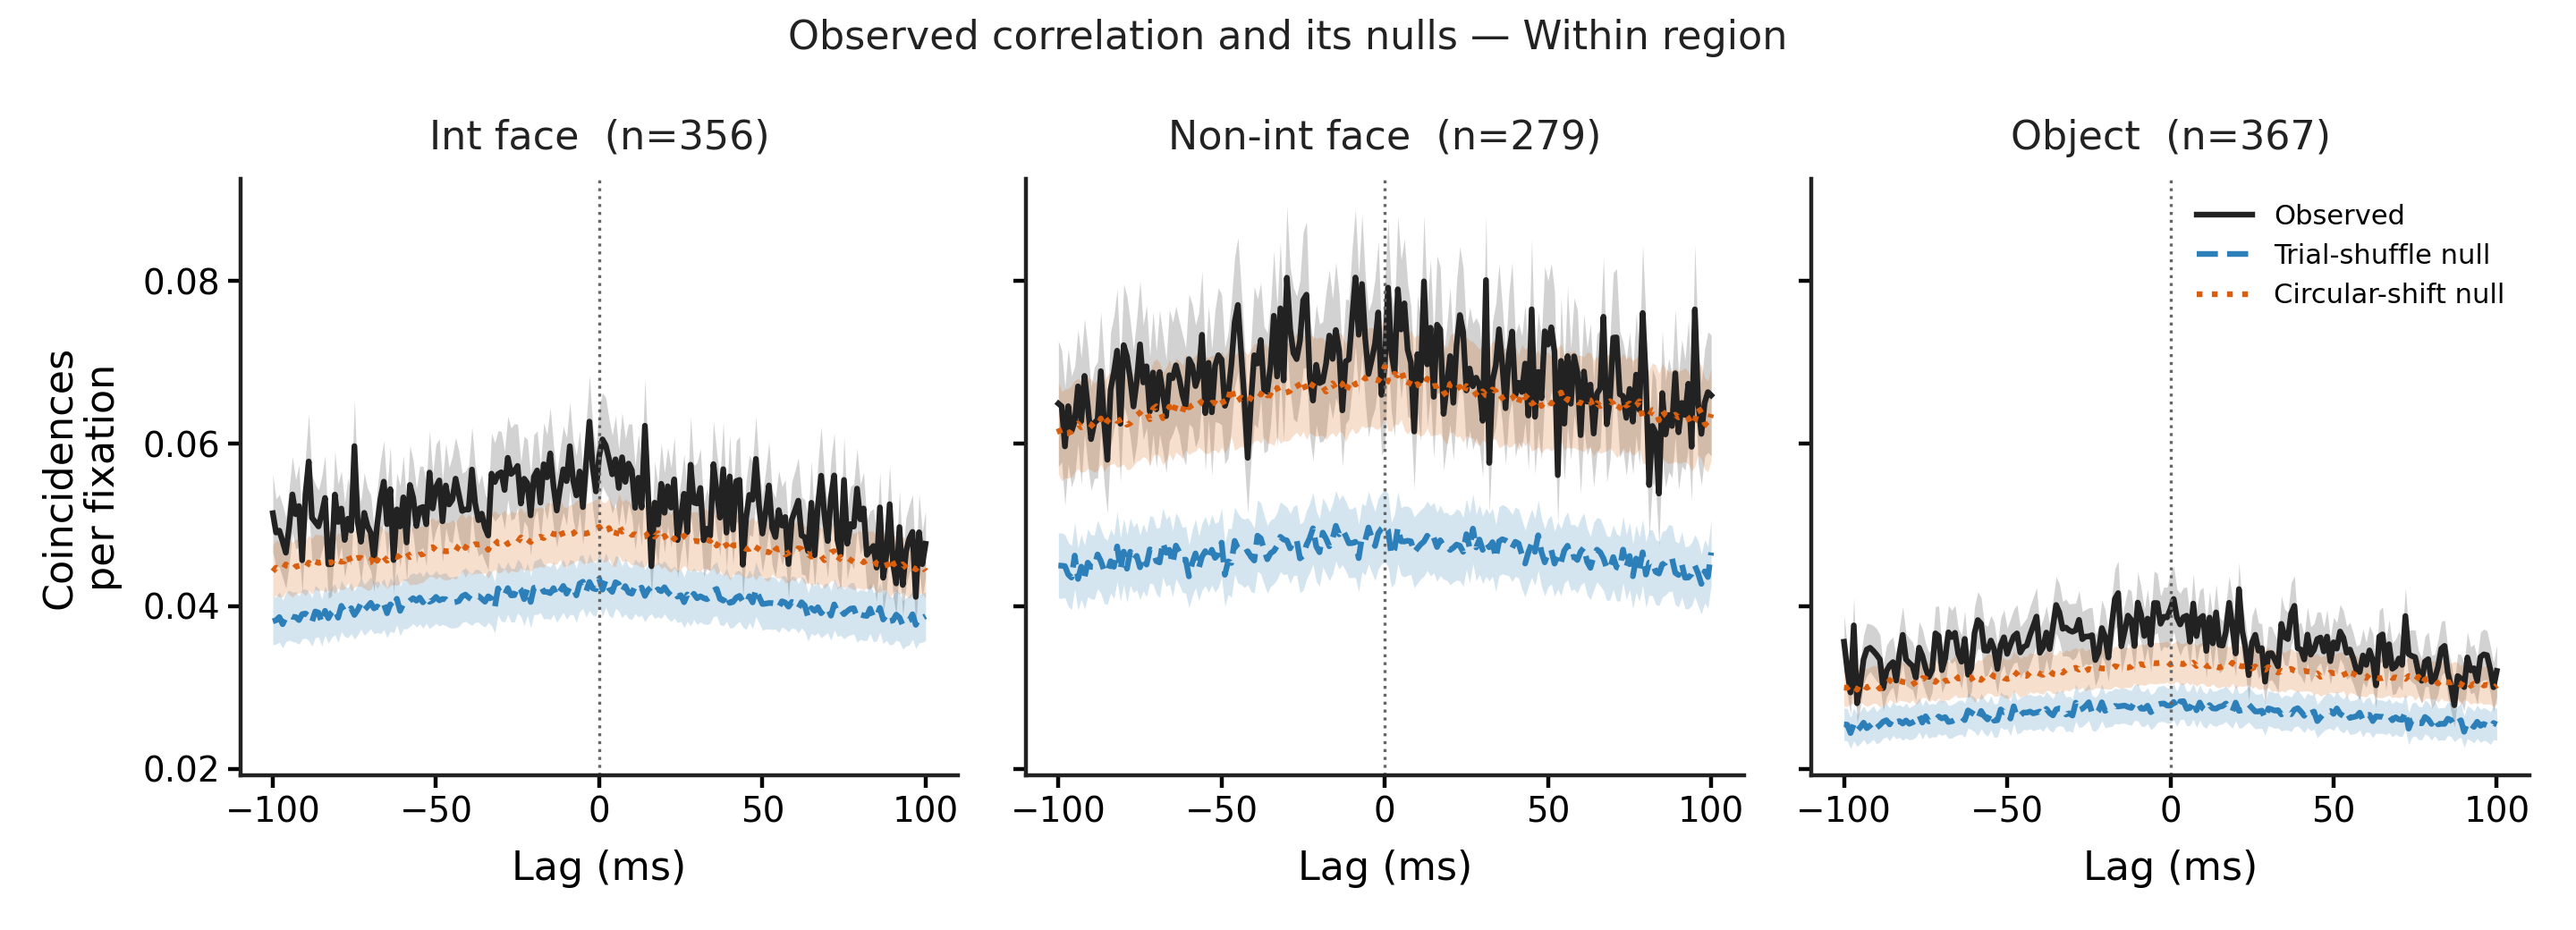

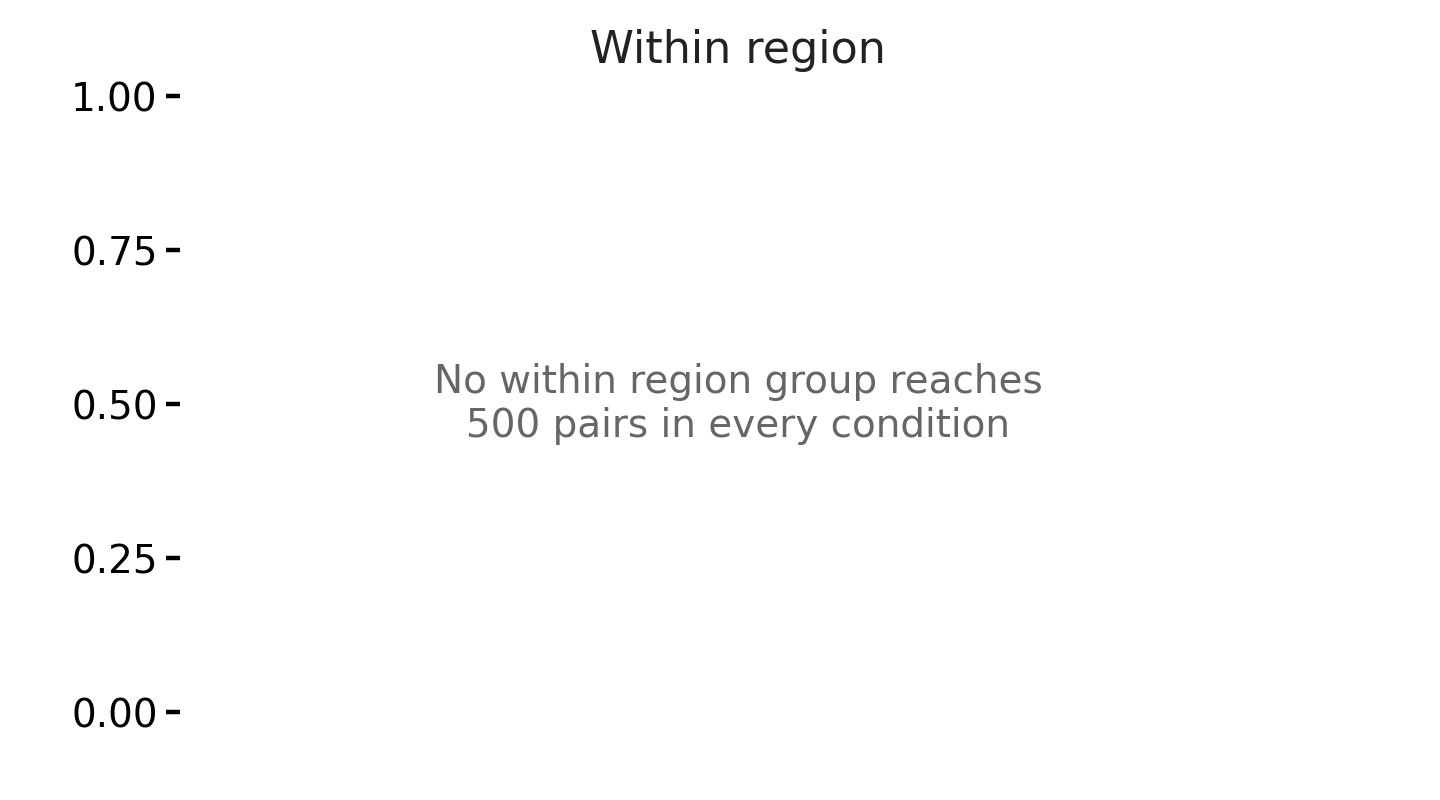

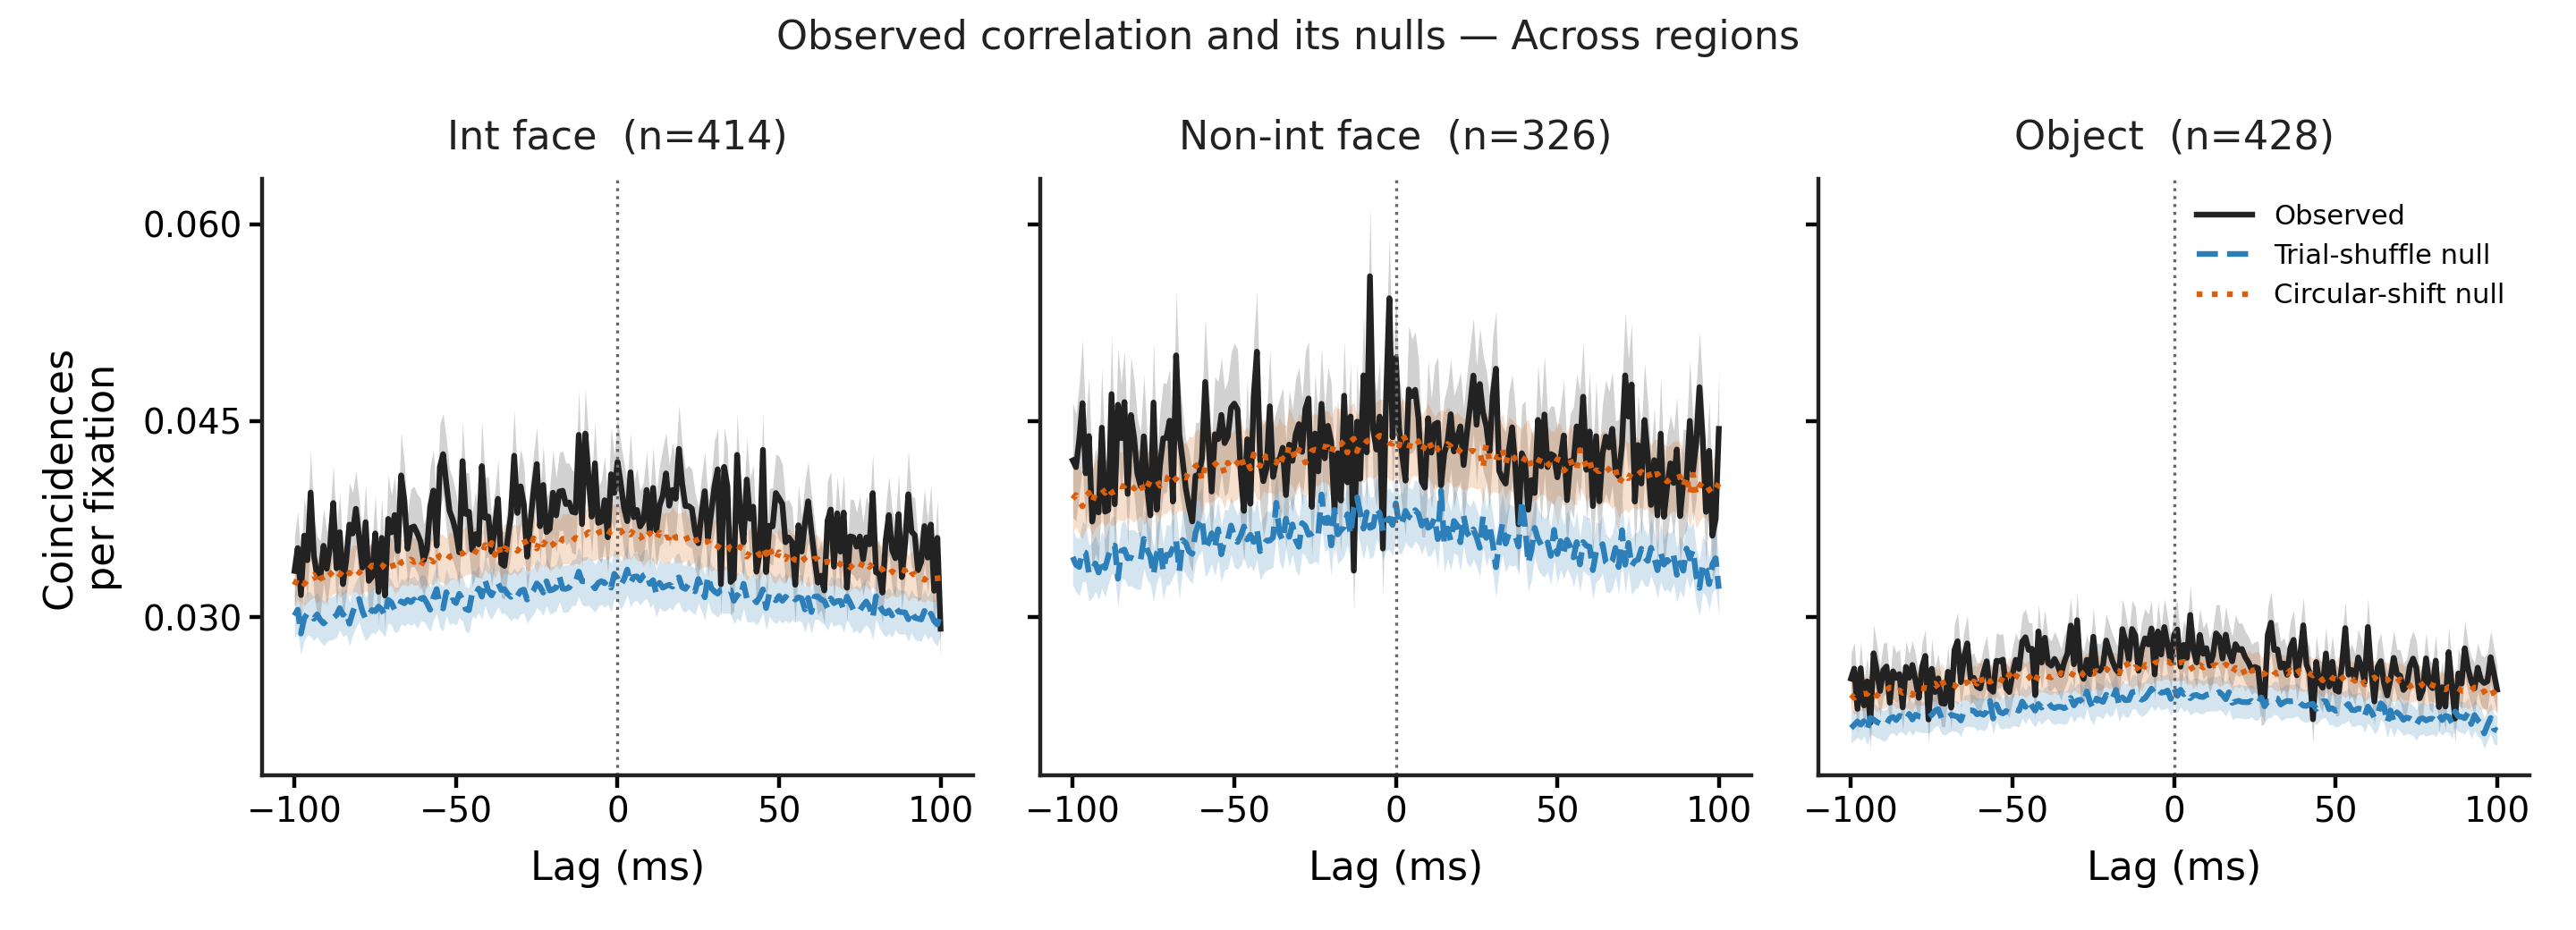

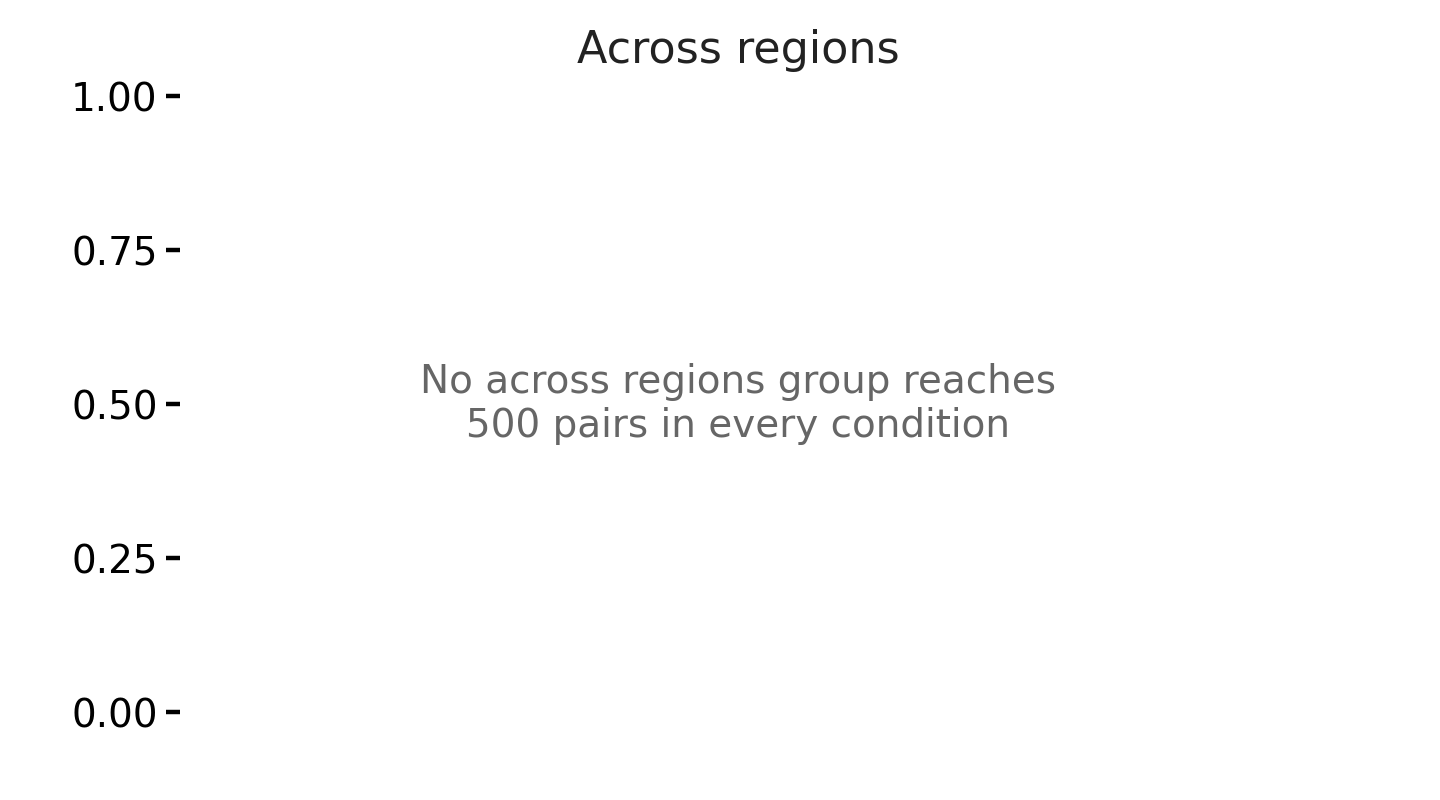

In [13]:
selective = pairs.loc[pairs["both_selective"]]
print(f"pairs with both units FDR-selective: {len(selective):,} of {len(pairs):,} "
      f"({len(selective) / max(len(pairs), 1):.1%})")
display(psc.build_pair_inventory(selective))

sel_by_scope = pd.read_pickle(SUMMARY_DIR / "group_traces_selective.pkl")
sel_by_region = pd.read_pickle(SUMMARY_DIR / "group_traces_by_region_selective.pkl")

for scope in ("within_region", "cross_region"):
    fig, paths = viz.plot_observed_and_nulls(
        sel_by_scope, fig_settings, scope=scope, stem="fig10_observed_and_nulls_selective"
    )
    display(Image(filename=str(paths["png"])))
    fig, paths = viz.plot_region_traces(
        sel_by_region, fig_settings, scope=scope, null_name=NULL, metric="ratio",
        label="FDR-selective", min_pairs=MIN_PAIRS,
        stem="fig11_region_traces_selective",
    )
    display(Image(filename=str(paths["png"])))

### Selective-pair contrasts, against the all-pair result

The final table puts the two side by side on the same rows, so a difference in
conclusion is visible directly rather than inferred by comparing two tables.

,scope,region_pair,condition_a,condition_b,n_pairs,mean_a,mean_b,mean_difference,statistic,p_value,effect_size_rank_biserial,p_value_corrected,significant,pvalue_correction
0,cross_region,accg-bla,face_interactive,face_non_interactive,312,0.3736,0.3569,0.0167,23025.5,0.5575,0.0291,0.6272,False,fdr_bh
1,cross_region,accg-bla,face_interactive,object,400,0.6670,0.5048,0.1622,38557.0,0.8093,-0.0025,0.8093,False,fdr_bh
2,cross_region,accg-bla,face_non_interactive,object,326,0.3186,0.3785,-0.0599,23797.0,0.1873,-0.0807,0.2964,False,fdr_bh
3,within_region,accg,face_interactive,face_non_interactive,146,0.5666,0.7168,-0.1502,4210.0,0.0326,-0.1448,0.2937,False,fdr_bh
4,within_region,accg,face_interactive,object,183,1.2011,1.9959,-0.7948,7715.0,0.3902,-0.0659,0.5017,False,fdr_bh
5,within_region,accg,face_non_interactive,object,146,0.7168,0.8243,-0.1076,4630.0,0.1910,0.0759,0.2964,False,fdr_bh
6,within_region,bla,face_interactive,face_non_interactive,121,0.3831,0.2285,0.1547,3087.0,0.1550,0.1500,0.2964,False,fdr_bh
7,within_region,bla,face_interactive,object,159,0.3747,0.2214,0.1533,5041.0,0.1218,0.0588,0.2964,False,fdr_bh
8,within_region,bla,face_non_interactive,object,133,0.1372,0.2617,-0.1245,3703.0,0.1976,-0.1231,0.2964,False,fdr_bh


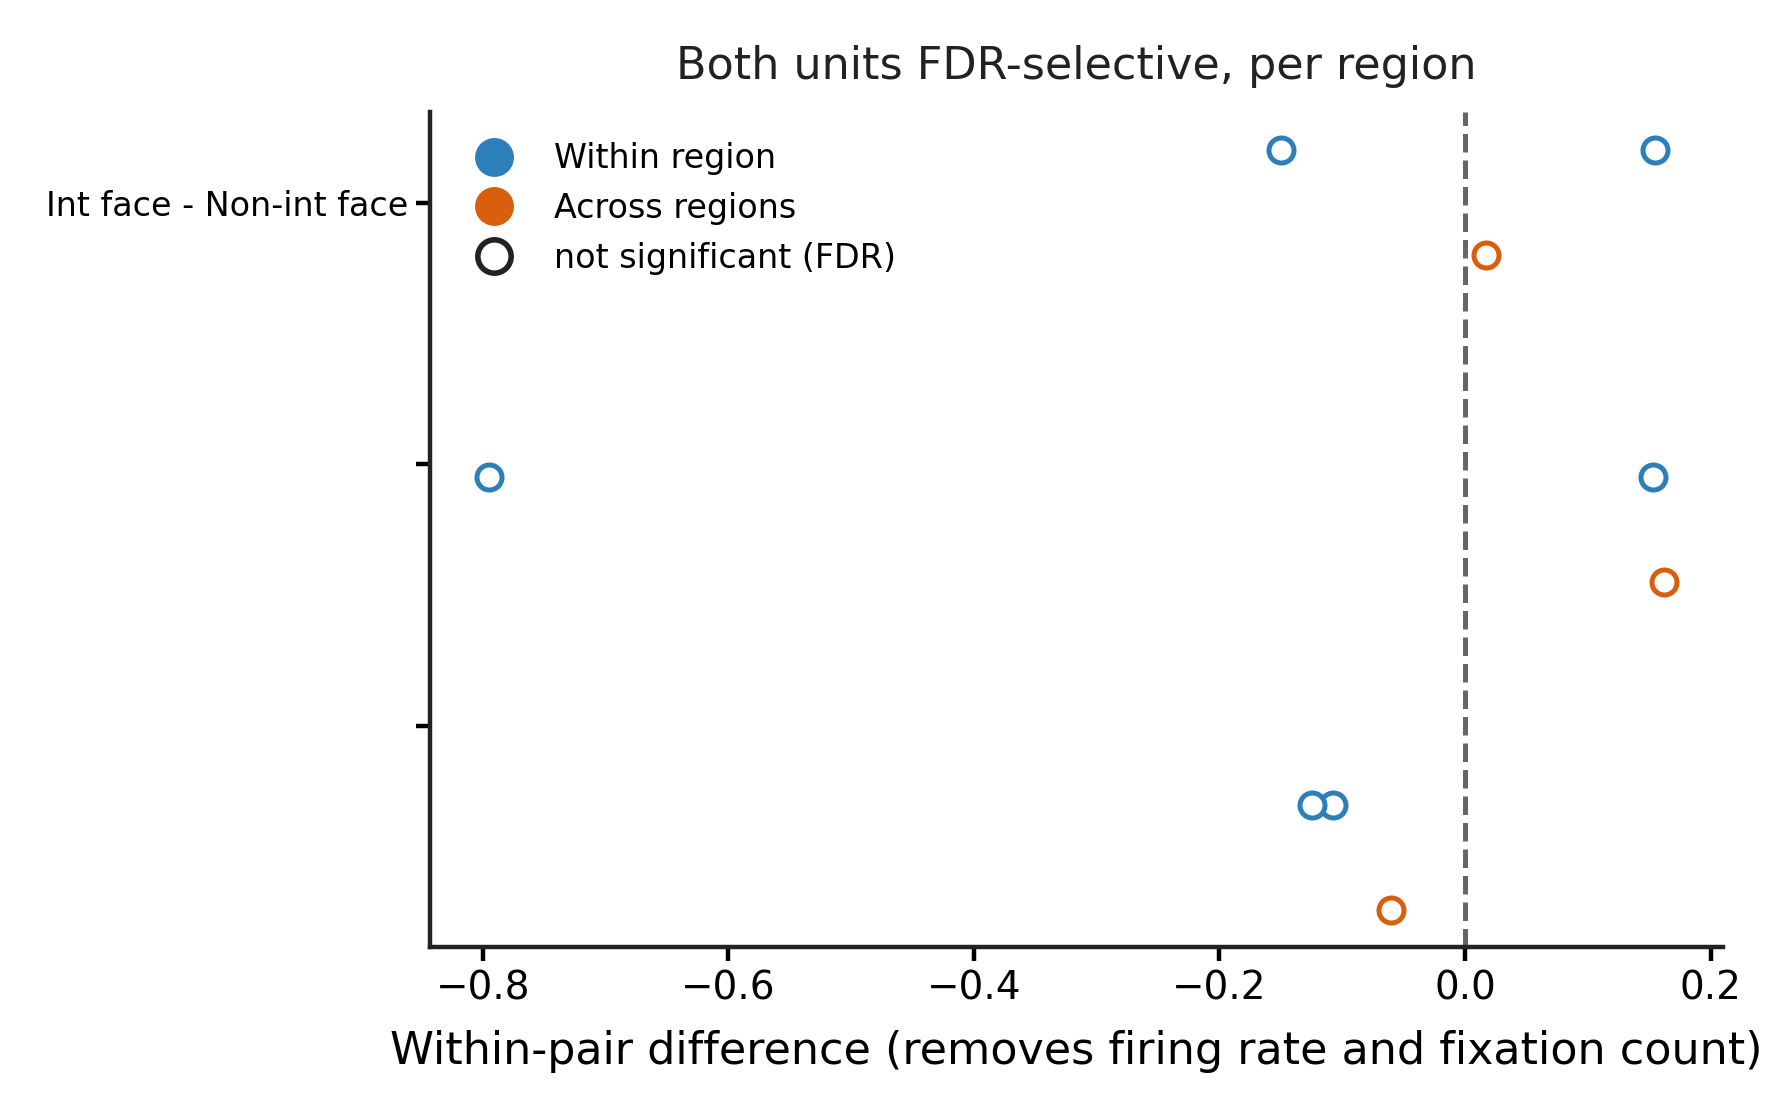

,scope,region_pair,condition_a,condition_b,n_pairs_all,mean_difference_all,significant_all,n_pairs_selective,mean_difference_selective,significant_selective
0,cross_region,accg-bla,face_interactive,face_non_interactive,639,0.0097,False,312,0.0167,False
1,cross_region,accg-bla,face_interactive,object,844,0.0039,False,400,0.1622,False
2,cross_region,accg-bla,face_non_interactive,object,648,-0.1646,False,326,-0.0599,False
3,within_region,accg,face_interactive,face_non_interactive,258,-0.1955,True,146,-0.1502,False
4,within_region,accg,face_interactive,object,316,-0.4797,False,183,-0.7948,False
5,within_region,accg,face_non_interactive,object,258,0.0207,True,146,-0.1076,False
6,within_region,bla,face_interactive,face_non_interactive,318,-0.0654,False,121,0.1547,False
7,within_region,bla,face_interactive,object,455,0.3292,True,159,0.1533,False
8,within_region,bla,face_non_interactive,object,328,0.0656,False,133,-0.1245,False


In [14]:
sel_contrasts = pd.read_csv(SUMMARY_DIR / "condition_comparisons_by_region_selective.csv")
display(sel_contrasts.round(4))

fig, paths = viz.plot_condition_contrasts(
    sel_contrasts, fig_settings,
    label="Both units FDR-selective, per region", stem="fig12_contrasts_selective",
)
display(Image(filename=str(paths["png"])))

# Side by side with the all-pairs result on the same rows.
side_by_side = by_region_contrasts.merge(
    sel_contrasts, on=["scope", "region_pair", "condition_a", "condition_b"],
    suffixes=("_all", "_selective"),
)
display(
    side_by_side.loc[
        :,
        ["scope", "region_pair", "condition_a", "condition_b",
         "n_pairs_all", "mean_difference_all", "significant_all",
         "n_pairs_selective", "mean_difference_selective", "significant_selective"],
    ].round(4)
)

## 10. The zero-lag artifact — already removed

Days carrying the zero-lag artifact are **dropped from every result above**, not
checked afterwards. The artifact is a property of the recording, so leaving it
in and noting it at the end would mean every headline number carries it.

The chance that two randomly sampled neurons are monosynaptically connected is
near zero, so a sharp zero-lag peak shared by most pairs on a day is common
input — movement, arousal, or a shared reference/ground artifact. The signature
separating it from a real effect is that it is a property of the **day and
array**, not of the pair: on a contaminated day nearly every simultaneously
recorded pair shows it, including pairs sharing nothing else.

This section reports which days were removed and why.

_No date was flagged, so nothing was removed._

,date,scope,n_pairs,mean_zero_lag_z,median_zero_lag_z,frac_pairs_zero_lag_above,mean_zero_lag_sharpness,suspected_zero_lag_artifact
0,1312018,cross_region,2440,0.1217,-0.2919,0.0365,0.0412,False
1,1312018,within_region,2237,0.0661,-0.3656,0.0447,-0.0464,False


_No date stands out as a zero-lag outlier._

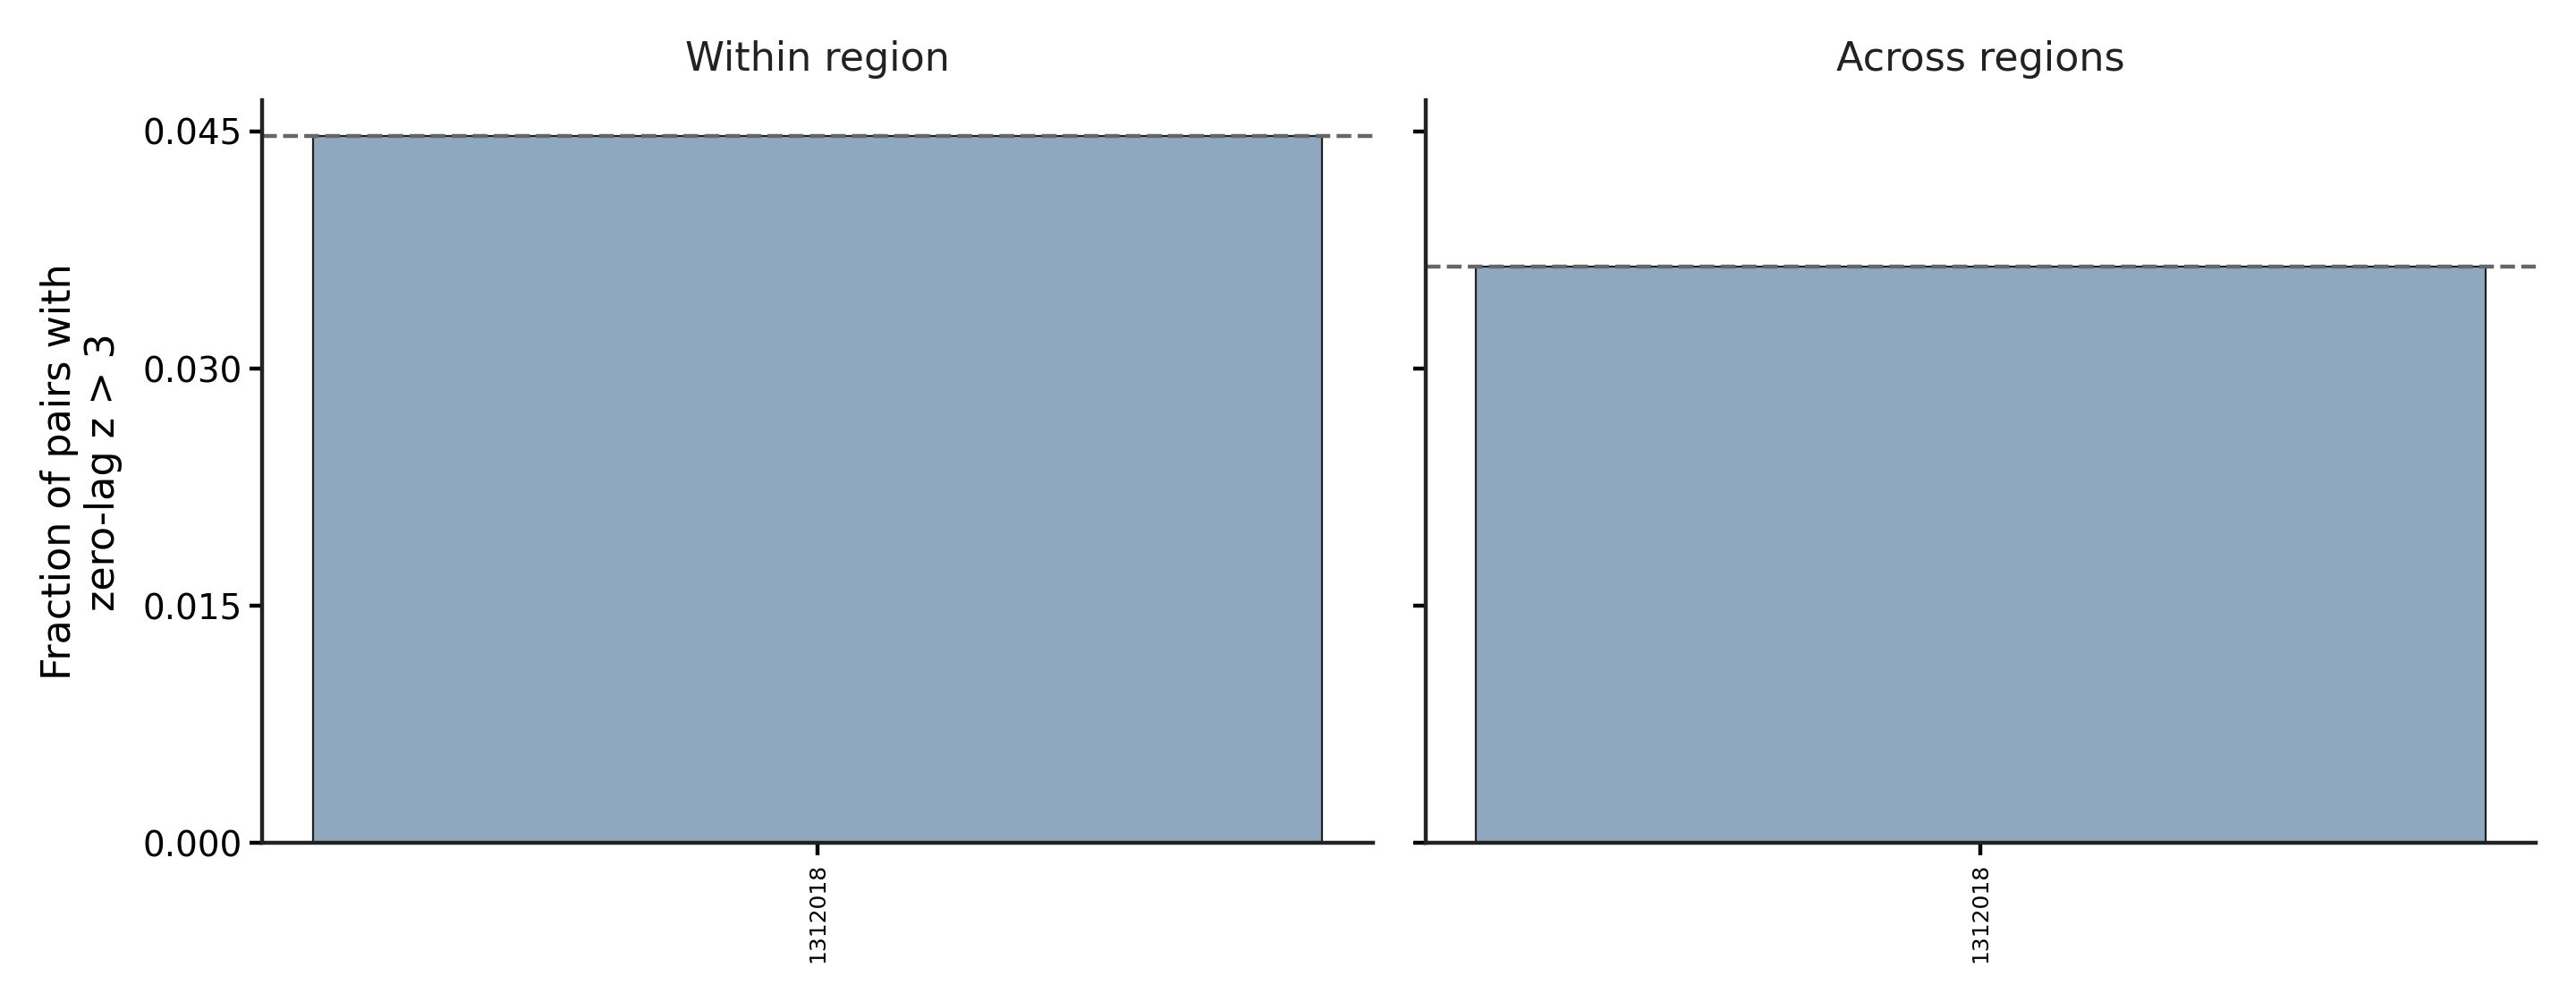

In [15]:
dropped = pd.read_csv(SUMMARY_DIR / "dropped_artifact_dates.csv")
if len(dropped):
    display(Markdown(
        f"**{len(dropped)} date(s) were removed from every result above**: "
        f"{sorted(dropped['date'].astype(str))}"
    ))
else:
    display(Markdown("_No date was flagged, so nothing was removed._"))

diagnostics = pd.read_csv(SUMMARY_DIR / "zero_lag_diagnostics.csv")
display(diagnostics.round(4))

flagged = diagnostics.loc[diagnostics["suspected_zero_lag_artifact"].fillna(False)]
if len(flagged):
    display(Markdown(
        f"**{len(flagged)} date/scope combinations flagged.** "
        f"Dates: {sorted(flagged['date'].unique())}"
    ))
else:
    display(Markdown("_No date stands out as a zero-lag outlier._"))

fig, paths = viz.plot_zero_lag_diagnostics(diagnostics, fig_settings)
display(Image(filename=str(paths["png"])))

## 11. What the flagged days would have done

The reported result already excludes them. This puts them back for comparison,
so the size of the artifact's influence is visible rather than asserted.

In [16]:
all_days = pd.read_csv(SUMMARY_DIR / "condition_comparisons_by_region_all_days.csv")
side = by_region_contrasts.merge(
    all_days, on=["scope", "region_pair", "condition_a", "condition_b"],
    suffixes=("_clean", "_all_days"),
)
display(
    side.loc[
        :,
        ["scope", "region_pair", "condition_a", "condition_b",
         "mean_difference_clean", "significant_clean",
         "mean_difference_all_days", "significant_all_days"],
    ].round(4)
)
changed = side.loc[side["significant_clean"] != side["significant_all_days"]]
if len(changed):
    display(Markdown(
        f"**{len(changed)} contrast(s) change significance when the flagged days are "
        "put back.** The reported result is the one with them removed."
    ))
else:
    display(Markdown(
        "_No contrast changes when the flagged days are put back, so no conclusion "
        "rests on them._"
    ))

,scope,region_pair,condition_a,condition_b,mean_difference_clean,significant_clean,mean_difference_all_days,significant_all_days
0,cross_region,accg-bla,face_interactive,face_non_interactive,0.0097,False,0.0097,False
1,cross_region,accg-bla,face_interactive,object,0.0039,False,0.0039,False
2,cross_region,accg-bla,face_non_interactive,object,-0.1646,False,-0.1646,False
3,within_region,accg,face_interactive,face_non_interactive,-0.1955,True,-0.1955,True
4,within_region,accg,face_interactive,object,-0.4797,False,-0.4797,False
5,within_region,accg,face_non_interactive,object,0.0207,True,0.0207,True
6,within_region,bla,face_interactive,face_non_interactive,-0.0654,False,-0.0654,False
7,within_region,bla,face_interactive,object,0.3292,True,0.3292,True
8,within_region,bla,face_non_interactive,object,0.0656,False,0.0656,False


_No contrast changes when the flagged days are put back, so no conclusion rests on them._